# 2026-08-27 Paper II Q1: first-order transformation of resolved star formation through RPS

**Scientific question:** How does the resolved star-forming population transform from pre-peak, through close-to-peak, to post-peak environmental processing?

This notebook deliberately separates two observables:

1. **SF survival/disappearance:** at fixed local stellar surface density, what fraction of the usable MUSE footprint is still classified as star forming?
2. **SFR intensity of survivors:** among the regions still classified as star forming, is their SFR surface density different from the galaxy-equal pre-peak reference?

Throughout this notebook, **star forming** means the combined project selection: a finite value in the relevant `_HII` (primary) or `_SF` (robustness) SFR map, `PROXY_EWHA > 6` Angstrom, and intrinsic Halpha velocity dispersion `< 45 km/s`. The intrinsic dispersion is $\sqrt{\sigma_{\rm obs}^2-\sigma_{\rm corr}^2}$.

The central result is the combination of

$$f_{\rm SF}(\Sigma_\star)$$

and

$$\Delta\log\Sigma_{\rm SFR,surv}(\Sigma_\star).$$

Native MUSE pixels and repeated pixels within one bin are spatially correlated. **Galaxies, not pixels, are the independent environmental units.** Pixels measure within-galaxy area fractions and distributions; all stage inference resamples or summarises entire galaxies.

## Scope

This notebook is Q1 only. It does **not** analyse metallicity, $\Delta Z-\Delta\Sigma_{\rm SFR}$, directional enhancement, wind direction, electron density, gas pressure, resolved H I, or resolved H$_2$.

## Hypotheses (tests, not assumptions)

- H1: low-$\Sigma_\star$ SF progressively disappears across the stage sequence.
- H2: surviving low/intermediate-$\Sigma_\star$ regions are suppressed post-peak.
- H3: surviving high-$\Sigma_\star$ regions are comparatively resilient.
- H4: determine whether these patterns are primarily radial/outside-in or whether $\Sigma_\star$ adds information at fixed $R/R_e$.

Do not interpret $\Sigma_\star$ itself as a Gunn--Gott restoring pressure. Report observational behaviour before causal language.


## 1. Configuration

All paths, HDUs, technical cuts, and analysis grids live here. Technical minima control stability and support; they are not tuned scientific thresholds. Figure and CSV saving is disabled by default and must not be enabled unless outputs are explicitly requested.


In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
DATA_ROOT = PROJECT_ROOT / "v3tk_v7.6.8"
CATALOG_PATH = PROJECT_ROOT / "mauve_master_wiki_newclass.fits"
GEOMETRY_PATH = PROJECT_ROOT / "MAUVE_effective_radii.csv"
GALAXY_COLOR_PATH = PROJECT_ROOT / "MAUVE_galaxy_colors.dat"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "paper2_Q1_first_order_SF"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
DIAGNOSTIC_DIR = OUTPUT_DIR / "diagnostics"

MASS_FILE_PATTERN = "{galid}_spatial_binning_maps_further.fits"
SFR_FILE_PATTERNS = (
    "{galid}_gas_bin_maps_further.fits",
    "{galid}_gas_BIN_maps_further.fits",
)
EW_FILE_PATTERNS = (
    "{galid}_proxy_EW_maps_further.fits",
    "{galid}_proxy_EW_maps.fits",
)
MASK_FILE_PATTERN = "{galid}_mask.fits"

MASS_HDU = "LOGMASS_SURFACE_DENSITY"
BIN_HDU_MASS = "BINID"
BIN_HDU_GAS = "BIN_ID"
SFR_HDU_PRIMARY = "LOGSFR_SURFACE_DENSITY_HII"
SFR_HDU_ROBUST = "LOGSFR_SURFACE_DENSITY_SF"
EW_HDU = "PROXY_EWHA"
EW_HA_MIN = 6.0
HALPHA_SIGMA_OBS_HDU = "HA6562_SIGMA"
HALPHA_SIGMA_CORR_HDU = "HA6562_SIGMA_CORR"
HALPHA_SIGMA_MAX = 45.0
MASK_TABLE_HDU = "MASKFILE"
MASK_COLUMN = "MASK"               # live nGIST convention: 0 usable, 1 masked

N_SIGMA_BINS = 12
SIGMA_RANGE = (6.0, 10.0)          # fixed common grid; unsupported bins are masked later
R_EDGES = __import__('numpy').arange(0.0, 1.6 + 0.2, 0.2)
N_RADIUS_2D_BINS = len(R_EDGES) - 1

I_MAX_PRIMARY = 80.0
I_MAX_ROBUSTNESS = (60.0, 65.0, 70.0, 80.0)
N_BOOTSTRAP = 10_000
RANDOM_SEED = 42

MIN_VALID_PIXELS_PER_BIN = 50
MIN_SF_PIXELS_PER_BIN = 20
MIN_GALAXIES_PER_STAGE_BIN = 3
MIN_GALAXIES_PER_2D_CELL = 3
WCS_TOLERANCE_ARCSEC = 0.05
STRICT_VALIDATION = True
EXCLUDED_GALAXIES = {}             # mapping GALID -> explicit reason; empty by design
SAVE_OUTPUTS = False             # enable only when figure/CSV output is explicitly requested

STAGE_ORDER = ("pre-peak", "close-to-peak", "post-peak")
STAGE_COLORS = {
    "pre-peak": "#2166ac",
    "close-to-peak": "#1a9850",
    "post-peak": "#d73027",
}

if SAVE_OUTPUTS:
    for path in (FIGURE_DIR, TABLE_DIR, DIAGNOSTIC_DIR):
        path.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data root: {DATA_ROOT}")
print(f"Outputs: {OUTPUT_DIR}")
print("No additional inclination correction will be applied to either surface-density map.")
print(f"SF selection: finite HII/SF map + {EW_HDU}>{EW_HA_MIN:g} Angstrom + intrinsic Halpha sigma<{HALPHA_SIGMA_MAX:g} km/s")


Project root: /Users/Igniz/Desktop/ICRAR/further
Data root: /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8
Outputs: /Users/Igniz/Desktop/ICRAR/further/outputs/paper2_Q1_first_order_SF
No additional inclination correction will be applied to either surface-density map.
SF selection: finite HII/SF map + PROXY_EWHA>6 Angstrom + intrinsic Halpha sigma<45 km/s


## 2. Imports and reusable helpers

The helpers below enforce explicit product discovery, WCS/shape checks, component-aware geometry for `NGC4567_8`, galaxy-level summaries, and whole-galaxy bootstrap resampling.


In [2]:
from __future__ import annotations

import math
import warnings
from dataclasses import dataclass

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from IPython.display import display
from scipy.special import expit

RNG = np.random.default_rng(RANDOM_SEED)
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.grid": False,
})


def save_table(frame: pd.DataFrame, filename: str) -> Path:
    path = TABLE_DIR / filename
    if SAVE_OUTPUTS:
        frame.to_csv(path, index=False)
    return path


def save_figure(fig, stem: str, *, diagnostic: bool = False):
    directory = DIAGNOSTIC_DIR if diagnostic else FIGURE_DIR
    if SAVE_OUTPUTS:
        fig.savefig(directory / f"{stem}.png", dpi=300, bbox_inches="tight")
        fig.savefig(directory / f"{stem}.pdf", bbox_inches="tight")


def normalise_stage_label(value) -> str:
    mapping = {
        1: "pre-peak", 1.0: "pre-peak", "1": "pre-peak",
        2: "close-to-peak", 2.0: "close-to-peak", "2": "close-to-peak",
        3: "post-peak", 3.0: "post-peak", "3": "post-peak",
        "prepeak": "pre-peak", "pre-peak": "pre-peak",
        "close-to-peak": "close-to-peak", "closetopeak": "close-to-peak",
        "near-peak": "close-to-peak", "postpeak": "post-peak",
        "post-peak": "post-peak",
    }
    key = value if isinstance(value, (int, float)) else str(value).strip().lower().replace(" ", "")
    if key not in mapping:
        raise ValueError(f"Unrecognised RPS/infall stage label: {value!r}")
    return mapping[key]


def first_existing(paths):
    for path in paths:
        if path.exists():
            return path
    return None


def load_fits_map(path: Path, hdu_name: str, *, return_header: bool = False):
    if not path.exists():
        raise FileNotFoundError(path)
    with fits.open(path, memmap=True) as hdul:
        names = {h.name.upper() for h in hdul}
        if hdu_name.upper() not in names:
            raise KeyError(f"{path}: missing HDU {hdu_name}; available={sorted(names)}")
        hdu = hdul[hdu_name]
        data = np.asarray(hdu.data, dtype=float).copy()
        header = hdu.header.copy()
    return (data, header) if return_header else data


def load_ngist_mask(path: Path, shape):
    if not path.exists():
        raise FileNotFoundError(path)
    with fits.open(path, memmap=True) as hdul:
        if MASK_TABLE_HDU not in hdul:
            raise KeyError(f"{path}: missing table HDU {MASK_TABLE_HDU}")
        table = hdul[MASK_TABLE_HDU].data
        if MASK_COLUMN not in table.names:
            raise KeyError(f"{path}: missing mask column {MASK_COLUMN}; available={table.names}")
        flat = np.asarray(table[MASK_COLUMN], dtype=int)
    if flat.size != int(np.prod(shape)):
        raise ValueError(f"{path}: mask length {flat.size} cannot reshape to {shape}")
    return flat.reshape(shape)


def celestial_wcs_separation_arcsec(header_a, header_b, shape):
    wa = WCS(header_a).celestial
    wb = WCS(header_b).celestial
    if not wa.has_celestial or not wb.has_celestial:
        return np.inf
    ny, nx = shape
    x = np.array([0, nx - 1, 0, nx - 1, (nx - 1) / 2])
    y = np.array([0, 0, ny - 1, ny - 1, (ny - 1) / 2])
    raa, deca = wa.pixel_to_world_values(x, y)
    rab, decb = wb.pixel_to_world_values(x, y)
    cosd = np.cos(np.deg2rad((deca + decb) / 2))
    return float(np.nanmax(np.hypot((raa - rab) * cosd, deca - decb)) * 3600.0)


def tangent_offsets_arcsec(ra_deg, dec_deg, ra0_deg, dec0_deg):
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    ra0, dec0 = np.deg2rad(float(ra0_deg)), np.deg2rad(float(dec0_deg))
    dra = (ra - ra0 + np.pi) % (2 * np.pi) - np.pi
    cosc = np.sin(dec0) * np.sin(dec) + np.cos(dec0) * np.cos(dec) * np.cos(dra)
    with np.errstate(divide="ignore", invalid="ignore"):
        east = np.cos(dec) * np.sin(dra) / cosc
        north = (np.cos(dec0) * np.sin(dec) - np.sin(dec0) * np.cos(dec) * np.cos(dra)) / cosc
    return east * 206264.806247, north * 206264.806247


def calculate_deprojected_radius(shape, header, component_rows: pd.DataFrame):
    """Return min elliptical R/Re over physical components (union geometry for NGC4567_8)."""
    wcs = WCS(header).celestial
    if not wcs.has_celestial:
        raise ValueError("No celestial WCS available for radius calculation")
    yy, xx = np.indices(shape, dtype=float)
    ra, dec = wcs.pixel_to_world_values(xx, yy)
    radius = np.full(shape, np.inf, dtype=float)
    for _, row in component_rows.iterrows():
        east, north = tangent_offsets_arcsec(ra, dec, row.center_ra_deg, row.center_dec_deg)
        pa = np.deg2rad(float(row.pa_deg_east_of_north))
        major = east * np.sin(pa) + north * np.cos(pa)
        minor = east * np.cos(pa) - north * np.sin(pa)
        r = np.sqrt((major / float(row.a_re_arcsec)) ** 2 + (minor / float(row.b_re_arcsec)) ** 2)
        radius = np.minimum(radius, r)
    radius[~np.isfinite(radius)] = np.nan
    return radius


def make_valid_disc_mask(log_sigma_star, bin_id, ngist_mask, radius_re):
    return (
        np.isfinite(log_sigma_star)
        & np.isfinite(bin_id)
        & (ngist_mask == 0)
        & np.isfinite(radius_re)
    )


def intrinsic_sigma_from_maps(sigma_obs, sigma_corr):
    sigma_obs = np.asarray(sigma_obs, dtype=float)
    sigma_corr = np.asarray(sigma_corr, dtype=float)
    if sigma_obs.shape != sigma_corr.shape:
        raise ValueError(
            f"Observed/correction Halpha sigma shape mismatch: {sigma_obs.shape} vs {sigma_corr.shape}"
        )
    sigma2_intrinsic = sigma_obs**2 - sigma_corr**2
    sigma_intrinsic = np.full(sigma_obs.shape, np.nan, dtype=float)
    valid = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
    sigma_intrinsic[valid] = np.sqrt(sigma2_intrinsic[valid])
    return sigma_intrinsic


def make_sf_mask(valid_disc_mask, log_sigma_sfr, ew_ha, halpha_sigma_intrinsic):
    """Project SF definition: HII/SF map + EW(Halpha)>6 A + intrinsic sigma<45 km/s."""
    return (
        valid_disc_mask
        & np.isfinite(log_sigma_sfr)
        & np.isfinite(ew_ha)
        & (ew_ha > EW_HA_MIN)
        & np.isfinite(halpha_sigma_intrinsic)
        & (halpha_sigma_intrinsic < HALPHA_SIGMA_MAX)
    )


def load_galaxy_maps(row, geometry, sfr_hdu=SFR_HDU_PRIMARY):
    mass, mass_header = load_fits_map(row.mass_path, MASS_HDU, return_header=True)
    mass_bin = load_fits_map(row.mass_path, BIN_HDU_MASS)
    gas_bin, gas_header = load_fits_map(row.sfr_path, BIN_HDU_GAS, return_header=True)
    sfr = load_fits_map(row.sfr_path, sfr_hdu)
    ew_ha = load_fits_map(row.ew_path, EW_HDU)
    halpha_sigma_obs = load_fits_map(row.sfr_path, HALPHA_SIGMA_OBS_HDU)
    halpha_sigma_corr = load_fits_map(row.sfr_path, HALPHA_SIGMA_CORR_HDU)
    shapes = {
        mass.shape, mass_bin.shape, gas_bin.shape, sfr.shape, ew_ha.shape,
        halpha_sigma_obs.shape, halpha_sigma_corr.shape,
    }
    if len(shapes) != 1:
        raise ValueError(f"{row.GALID}: map shape mismatch {sorted(shapes)}")
    wcs_sep = celestial_wcs_separation_arcsec(mass_header, gas_header, mass.shape)
    if not np.isfinite(wcs_sep) or wcs_sep > WCS_TOLERANCE_ARCSEC:
        raise ValueError(f"{row.GALID}: mass/gas WCS mismatch {wcs_sep:.4f} arcsec")
    ngist_mask = load_ngist_mask(row.mask_path, mass.shape)
    components = geometry.loc[geometry.notebook_product_id.eq(row.GALID)].copy()
    if components.empty:
        raise KeyError(f"{row.GALID}: no geometry rows")
    radius_re = calculate_deprojected_radius(mass.shape, mass_header, components)
    halpha_sigma_intrinsic = intrinsic_sigma_from_maps(halpha_sigma_obs, halpha_sigma_corr)
    valid = make_valid_disc_mask(mass, gas_bin, ngist_mask, radius_re)
    classification = valid & np.isfinite(sfr)
    sf = make_sf_mask(valid, sfr, ew_ha, halpha_sigma_intrinsic)
    return {
        "log_sigma_star": mass,
        "log_sigma_sfr": sfr,
        "ew_ha": ew_ha,
        "halpha_sigma_intrinsic": halpha_sigma_intrinsic,
        "mass_bin_id": mass_bin,
        "gas_bin_id": gas_bin,
        "ngist_mask": ngist_mask,
        "radius_re": radius_re,
        "valid_disc_mask": valid,
        "classification_mask": classification,
        "sf_mask": sf,
        "wcs_separation_arcsec": wcs_sep,
    }


def binned_indices(values, edges):
    return np.digitize(values, edges, right=False) - 1


def measure_fsf_by_sigma(row, maps, sigma_edges, *, aperture=np.inf):
    records = []
    x = maps["log_sigma_star"]
    y = maps["log_sigma_sfr"]
    r = maps["radius_re"]
    valid_base = maps["valid_disc_mask"] & (r < aperture)
    sf_base = maps["sf_mask"] & (r < aperture)
    for j, (lo, hi) in enumerate(zip(sigma_edges[:-1], sigma_edges[1:])):
        valid = valid_base & (x >= lo) & (x < hi)
        sf = sf_base & (x >= lo) & (x < hi)
        n_valid, n_sf = int(valid.sum()), int(sf.sum())
        records.append({
            "GALID": row.GALID, "stage": row.stage,
            "logMstar_global": row.logMstar_global, "inclination": row.inclination,
            "aperture": "full" if np.isinf(aperture) else "within_Re",
            "sigma_bin": j, "sigma_bin_lo": lo, "sigma_bin_hi": hi,
            "sigma_bin_center": (lo + hi) / 2,
            "N_valid": n_valid, "N_SF": n_sf,
            "f_SF": n_sf / n_valid if n_valid >= MIN_VALID_PIXELS_PER_BIN else np.nan,
            "surv_logSigmaSFR_median": np.nanmedian(y[sf]) if n_sf >= MIN_SF_PIXELS_PER_BIN else np.nan,
            "surv_logSigmaSFR_p16": np.nanpercentile(y[sf], 16) if n_sf >= MIN_SF_PIXELS_PER_BIN else np.nan,
            "surv_logSigmaSFR_p84": np.nanpercentile(y[sf], 84) if n_sf >= MIN_SF_PIXELS_PER_BIN else np.nan,
            "surv_logSigmaSFR_p90": np.nanpercentile(y[sf], 90) if n_sf >= MIN_SF_PIXELS_PER_BIN else np.nan,
            "surv_logSigmaSFR_p95": np.nanpercentile(y[sf], 95) if n_sf >= MIN_SF_PIXELS_PER_BIN else np.nan,
        })
    return pd.DataFrame(records)


def measure_by_radius(row, maps, radius_edges):
    records = []
    r, y = maps["radius_re"], maps["log_sigma_sfr"]
    for j, (lo, hi) in enumerate(zip(radius_edges[:-1], radius_edges[1:])):
        geometry_pixels = np.isfinite(r) & (r >= lo) & (r < hi)
        valid = maps["valid_disc_mask"] & (r >= lo) & (r < hi)
        sf = maps["sf_mask"] & (r >= lo) & (r < hi)
        n_geometry, n_valid, n_sf = map(int, (geometry_pixels.sum(), valid.sum(), sf.sum()))
        records.append({
            "GALID": row.GALID, "stage": row.stage,
            "radius_bin": j, "radius_lo": lo, "radius_hi": hi, "radius_center": (lo + hi) / 2,
            "N_geometry": n_geometry, "N_valid": n_valid, "N_SF": n_sf,
            "f_coverage": n_valid / n_geometry if n_geometry else np.nan,
            "f_SF": n_sf / n_valid if n_valid >= MIN_VALID_PIXELS_PER_BIN else np.nan,
            "surv_logSigmaSFR_median": np.nanmedian(y[sf]) if n_sf >= MIN_SF_PIXELS_PER_BIN else np.nan,
        })
    return pd.DataFrame(records)


def measure_fsf_2d(row, maps, sigma_edges, radius_edges):
    records = []
    x, r = maps["log_sigma_star"], maps["radius_re"]
    for i, (slo, shi) in enumerate(zip(sigma_edges[:-1], sigma_edges[1:])):
        for j, (rlo, rhi) in enumerate(zip(radius_edges[:-1], radius_edges[1:])):
            cell = (x >= slo) & (x < shi) & (r >= rlo) & (r < rhi)
            valid, sf = maps["valid_disc_mask"] & cell, maps["sf_mask"] & cell
            nv, ns = int(valid.sum()), int(sf.sum())
            records.append({
                "GALID": row.GALID, "stage": row.stage, "sigma_bin": i, "radius_bin": j,
                "sigma_center": (slo + shi) / 2, "radius_center": (rlo + rhi) / 2,
                "N_valid": nv, "N_SF": ns,
                "f_SF": ns / nv if nv >= MIN_VALID_PIXELS_PER_BIN else np.nan,
            })
    return pd.DataFrame(records)


def bootstrap_median(values, *, n_boot=N_BOOTSTRAP, rng=None):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.full(n_boot, np.nan)
    rng = RNG if rng is None else rng
    draws = rng.choice(values, size=(n_boot, values.size), replace=True)
    return np.nanmedian(draws, axis=1)


def stage_summary(frame, value_col, bin_col, *, min_galaxies=MIN_GALAXIES_PER_STAGE_BIN):
    rows = []
    for bin_value, bin_frame in frame.groupby(bin_col, sort=True):
        for stage in STAGE_ORDER:
            values = bin_frame.loc[bin_frame.stage.eq(stage), value_col].dropna().to_numpy()
            rec = {bin_col: bin_value, "stage": stage, "Ngal": len(values)}
            if len(values) >= min_galaxies:
                boot = bootstrap_median(values)
                rec.update({
                    "median": np.median(values), "scatter_p16": np.percentile(values, 16),
                    "scatter_p84": np.percentile(values, 84),
                    "boot_p2p5": np.percentile(boot, 2.5), "boot_p16": np.percentile(boot, 16),
                    "boot_p84": np.percentile(boot, 84), "boot_p97p5": np.percentile(boot, 97.5),
                })
            else:
                rec.update({k: np.nan for k in ["median", "scatter_p16", "scatter_p84", "boot_p2p5", "boot_p16", "boot_p84", "boot_p97p5"]})
            rows.append(rec)
    return pd.DataFrame(rows)


def add_prepeak_reference(frame):
    result = frame.copy()
    ref = (result.loc[result.stage.eq("pre-peak")]
           .groupby("sigma_bin")["surv_logSigmaSFR_median"].median()
           .rename("prepeak_reference"))
    result = result.merge(ref, on="sigma_bin", how="left", validate="many_to_one")
    result["surv_deltaSFR"] = result["surv_logSigmaSFR_median"] - result["prepeak_reference"]
    return result


def bootstrap_stage_difference(frame, value_col, bin_col, stage_a, stage_b):
    rows = []
    for bin_value, group in frame.groupby(bin_col, sort=True):
        a = group.loc[group.stage.eq(stage_a), value_col].dropna().to_numpy()
        b = group.loc[group.stage.eq(stage_b), value_col].dropna().to_numpy()
        rec = {bin_col: bin_value, "metric": value_col, "comparison": f"{stage_a}_minus_{stage_b}",
               "Ngal_a": len(a), "Ngal_b": len(b)}
        if min(len(a), len(b)) >= MIN_GALAXIES_PER_STAGE_BIN:
            rng = np.random.default_rng(RANDOM_SEED + int(bin_value) * 101 + len(rows))
            diff = bootstrap_median(a, rng=rng) - bootstrap_median(b, rng=rng)
            rec.update({
                "median_difference": np.median(diff), "p2p5": np.percentile(diff, 2.5),
                "p16": np.percentile(diff, 16), "p84": np.percentile(diff, 84),
                "p97p5": np.percentile(diff, 97.5),
                "fraction_above_zero": np.mean(diff > 0), "fraction_below_zero": np.mean(diff < 0),
            })
        else:
            rec.update({k: np.nan for k in ["median_difference", "p2p5", "p16", "p84", "p97p5", "fraction_above_zero", "fraction_below_zero"]})
        rows.append(rec)
    return pd.DataFrame(rows)


def plot_stage_summary(ax, summary, x_lookup, *, ylabel, title, zero=False):
    for stage in STAGE_ORDER:
        s = summary.loc[summary.stage.eq(stage)].sort_values(summary.columns[0])
        x = s[summary.columns[0]].map(x_lookup)
        supported = s.Ngal.ge(MIN_GALAXIES_PER_STAGE_BIN) & s["median"].notna()
        ax.plot(x[supported], s.loc[supported, "median"], marker="o", lw=2.4,
                color=STAGE_COLORS[stage], label=stage)
        ax.fill_between(x[supported], s.loc[supported, "scatter_p16"], s.loc[supported, "scatter_p84"],
                        color=STAGE_COLORS[stage], alpha=0.16, linewidth=0,
                        label="galaxy 16--84% scatter" if stage == STAGE_ORDER[0] else None)
    if zero:
        ax.axhline(0, color="0.3", ls="--", lw=1)
    ax.set(ylabel=ylabel, title=title)
    ax.grid(alpha=0.25)


## 3. Live catalogue and product inventory

Stages come from the master catalogue, never from H I deficiency. `NGC4567_8` is treated as one observational product only after verifying both physical components have the same stage. Its global mass is the sum of component stellar masses, its inclination cut is conservatively the maximum component inclination, and its radius map is the union/minimum-$R/R_e$ geometry of the two components.


In [3]:
def read_master_catalogue(path):
    with fits.open(path) as hdul:
        table = hdul[1].data
        required = {"Galaxy", "logMstar", "class"}
        missing = required - set(table.names)
        if missing:
            raise KeyError(f"{path}: missing catalogue columns {sorted(missing)}")
        frame = pd.DataFrame({
            "galaxy": [str(v).strip() for v in table["Galaxy"]],
            "logMstar": np.asarray(table["logMstar"], dtype=float),
            "stage_code": np.asarray(table["class"], dtype=float),
        })
    frame["stage"] = frame.stage_code.map(normalise_stage_label)
    return frame


def discover_products(data_root):
    rows = []
    for folder in sorted(p for p in data_root.iterdir() if p.is_dir() and not p.name.endswith("_logs")):
        galid = folder.name
        mass = folder / MASS_FILE_PATTERN.format(galid=galid)
        sfr = first_existing([folder / p.format(galid=galid) for p in SFR_FILE_PATTERNS])
        ew = first_existing([folder / p.format(galid=galid) for p in EW_FILE_PATTERNS])
        mask = folder / MASK_FILE_PATTERN.format(galid=galid)
        rows.append({"GALID": galid, "mass_path": mass, "sfr_path": sfr, "ew_path": ew, "mask_path": mask})
    return pd.DataFrame(rows)


master = read_master_catalogue(CATALOG_PATH)
geometry = pd.read_csv(GEOMETRY_PATH)
required_geometry = {
    "galaxy", "notebook_product_id", "mauve_infall_stage", "center_ra_deg", "center_dec_deg",
    "inclination_deg", "pa_deg_east_of_north", "a_re_arcsec", "b_re_arcsec",
}
missing_geometry = required_geometry - set(geometry.columns)
if missing_geometry:
    raise KeyError(f"{GEOMETRY_PATH}: missing columns {sorted(missing_geometry)}")
if geometry.galaxy.duplicated().any():
    raise ValueError("Geometry catalogue contains duplicate physical-galaxy rows")

geometry = geometry.merge(master[["galaxy", "logMstar", "stage"]], on="galaxy", how="left", validate="one_to_one")
if geometry[["logMstar", "stage"]].isna().any().any():
    raise RuntimeError("Geometry/master catalogue merge left missing mass or stage values")
geometry["stage_from_geometry"] = geometry.mauve_infall_stage.map(normalise_stage_label)
if not geometry.stage.eq(geometry.stage_from_geometry).all():
    bad = geometry.loc[~geometry.stage.eq(geometry.stage_from_geometry), ["galaxy", "stage", "stage_from_geometry"]]
    raise RuntimeError(f"Stage disagreement between catalogues:\n{bad}")

product_meta = []
for galid, group in geometry.groupby("notebook_product_id", sort=False):
    if group.stage.nunique() != 1:
        raise RuntimeError(f"{galid}: physical components have inconsistent stages")
    product_meta.append({
        "GALID": galid,
        "components": ",".join(group.galaxy),
        "stage": group.stage.iloc[0],
        "logMstar_global": np.log10(np.sum(10 ** group.logMstar.to_numpy())),
        "inclination": group.inclination_deg.max(),
    })
product_meta = pd.DataFrame(product_meta)

inventory = product_meta.merge(discover_products(DATA_ROOT), on="GALID", how="outer", validate="one_to_one")
inventory["manual_exclusion_reason"] = inventory.GALID.map(EXCLUDED_GALAXIES).fillna("")
inventory["analysis_candidate"] = inventory.manual_exclusion_reason.eq("")

def path_exists(value):
    return isinstance(value, Path) and value.exists()

inventory["mass_exists"] = inventory.mass_path.map(path_exists)
inventory["sfr_exists"] = inventory.sfr_path.map(path_exists)
inventory["ew_exists"] = inventory.ew_path.map(path_exists)
inventory["mask_exists"] = inventory.mask_path.map(path_exists)
inventory["catalogue_complete"] = inventory[["stage", "logMstar_global", "inclination"]].notna().all(axis=1)
display(inventory[["GALID", "components", "stage", "logMstar_global", "inclination",
                   "mass_exists", "sfr_exists", "ew_exists", "mask_exists", "manual_exclusion_reason"]])
print("Inventory stage counts:", inventory.groupby("stage").GALID.nunique().to_dict())


,GALID,components,stage,logMstar_global,inclination,mass_exists,sfr_exists,ew_exists,mask_exists,manual_exclusion_reason
0,IC3392,IC3392,post-peak,9.823572,68,True,True,True,True,
1,NGC4064,NGC4064,post-peak,10.046130,70,True,True,True,True,
2,NGC4189,NGC4189,pre-peak,9.734349,42,True,True,True,True,
3,NGC4192,NGC4192,pre-peak,10.764349,83,True,True,True,True,
4,NGC4216,NGC4216,post-peak,10.894349,90,False,False,False,False,
5,NGC4222,NGC4222,pre-peak,9.434349,90,True,True,True,True,
6,NGC4254,NGC4254,pre-peak,10.504350,39,True,True,True,True,
7,NGC4293,NGC4293,post-peak,10.526728,67,True,True,True,True,
8,NGC4294,NGC4294,pre-peak,9.364349,74,True,True,True,True,
9,NGC4298,NGC4298,close-to-peak,10.094349,52,True,True,True,True,


Inventory stage counts: {'close-to-peak': 10, 'post-peak': 18, 'pre-peak': 11}


## 4. Data validation and QC

Every discovered galaxy is audited. The QC table is saved before strict validation raises, so exclusions or missing products are never silent. A valid denominator requires a valid stellar-mass value, valid gas bin ID, `MASK==0`, and valid geometry; it does **not** require an H II detection, EW pass, or sigma pass. The SF numerator requires the full `_HII + EW(Halpha)>6 Angstrom + intrinsic sigma(Halpha)<45 km/s` selection.


In [4]:
qc_rows = []
for row in inventory.itertuples(index=False):
    flags = []
    maps = None
    if not row.analysis_candidate:
        flags.append(f"manual_exclusion:{row.manual_exclusion_reason}")
    for label, exists in (("mass", row.mass_exists), ("sfr", row.sfr_exists), ("ew", row.ew_exists), ("mask", row.mask_exists)):
        if not exists:
            flags.append(f"missing_{label}_product")
    if not row.catalogue_complete:
        flags.append("missing_catalogue_metadata")
    if not flags:
        try:
            maps = load_galaxy_maps(row, geometry, SFR_HDU_PRIMARY)
            valid, sf = maps["valid_disc_mask"], maps["sf_mask"]
            classified = maps["classification_mask"]
            if np.any(sf & ~valid):
                flags.append("sf_not_subset_of_valid")
        except Exception as exc:
            flags.append(f"load_error:{type(exc).__name__}:{exc}")
    valid = maps["valid_disc_mask"] if maps is not None else np.zeros(0, dtype=bool)
    sf = maps["sf_mask"] if maps is not None else np.zeros(0, dtype=bool)
    classified = maps["classification_mask"] if maps is not None else np.zeros(0, dtype=bool)
    qc_rows.append({
        "GALID": row.GALID, "components": row.components, "stage": row.stage,
        "logMstar_global": row.logMstar_global, "inclination": row.inclination,
        "N_valid_stellar_pixels": int(valid.sum()),
        "N_HII_classified_pixels_before_EW_sigma": int(classified.sum()),
        "N_HII_EW_sigma_SF_pixels": int(sf.sum()),
        "selected_SF_area_fraction": float(sf.sum() / valid.sum()) if valid.size and valid.sum() else np.nan,
        "max_usable_R_over_Re": float(np.nanmax(maps["radius_re"][valid])) if maps is not None and valid.any() else np.nan,
        "logSigmaStar_min": float(np.nanmin(maps["log_sigma_star"][valid])) if maps is not None and valid.any() else np.nan,
        "logSigmaStar_max": float(np.nanmax(maps["log_sigma_star"][valid])) if maps is not None and valid.any() else np.nan,
        "logSigmaSFR_min": float(np.nanmin(maps["log_sigma_sfr"][sf])) if maps is not None and sf.any() else np.nan,
        "logSigmaSFR_max": float(np.nanmax(maps["log_sigma_sfr"][sf])) if maps is not None and sf.any() else np.nan,
        "wcs_separation_arcsec": maps["wcs_separation_arcsec"] if maps is not None else np.nan,
        "QC_flag": ";".join(flags) if flags else "OK",
    })

qc = pd.DataFrame(qc_rows)
save_table(qc, "Q1_sample_QC.csv")
display(qc)
failures = qc.loc[qc.QC_flag.str.contains("load_error|sf_not_subset_of_valid|missing_catalogue_metadata", regex=True)]
if STRICT_VALIDATION and not failures.empty:
    raise RuntimeError("Strict validation failed. Inspect outputs/paper2_Q1_first_order_SF/tables/Q1_sample_QC.csv")

primary = inventory.loc[
    inventory.analysis_candidate & inventory.GALID.isin(qc.loc[qc.QC_flag.eq("OK"), "GALID"])
    & inventory.inclination.lt(I_MAX_PRIMARY)
].copy()
print(f"Primary i < {I_MAX_PRIMARY:.0f} deg sample: {len(primary)} products")
print(primary.groupby("stage").GALID.nunique().reindex(STAGE_ORDER, fill_value=0).to_dict())
if (primary.groupby("stage").GALID.nunique().reindex(STAGE_ORDER, fill_value=0) < MIN_GALAXIES_PER_STAGE_BIN).any():
    raise RuntimeError("Primary sample lacks the minimum galaxy count in at least one stage")


,GALID,components,stage,logMstar_global,inclination,N_valid_stellar_pixels,N_HII_classified_pixels_before_EW_sigma,N_HII_EW_sigma_SF_pixels,selected_SF_area_fraction,max_usable_R_over_Re,logSigmaStar_min,logSigmaStar_max,logSigmaSFR_min,logSigmaSFR_max,wcs_separation_arcsec,QC_flag
0,IC3392,IC3392,post-peak,9.823572,68,94575,14845,13897,0.146942,3.084733,6.969276,9.253759,-2.814456,-0.912330,0.0,OK
1,NGC4064,NGC4064,post-peak,10.046130,70,179882,7820,3273,0.018195,1.939061,6.811374,9.428892,-2.878540,-0.062300,0.0,OK
2,NGC4189,NGC4189,pre-peak,9.734349,42,177204,100340,96364,0.543803,2.270596,6.873473,9.774550,-3.243131,0.244948,0.0,OK
3,NGC4192,NGC4192,pre-peak,10.764349,83,524447,153872,144333,0.275210,2.209738,6.785489,10.584879,-3.711207,-0.247443,0.0,OK
4,NGC4216,NGC4216,post-peak,10.894349,90,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,missing_mass_product;missing_sfr_product;missi...
5,NGC4222,NGC4222,pre-peak,9.434349,90,259670,44054,42249,0.162703,6.734879,5.144392,8.537164,-4.122338,-0.244437,0.0,OK
6,NGC4254,NGC4254,pre-peak,10.504350,39,1043477,684002,661963,0.634382,4.060766,6.261151,10.597720,-3.477444,0.371030,0.0,OK
7,NGC4293,NGC4293,post-peak,10.526728,67,261523,4957,471,0.001801,1.842599,7.243091,10.336573,-2.516239,-0.939601,0.0,OK
8,NGC4294,NGC4294,pre-peak,9.364349,74,179355,69207,68833,0.383781,3.404326,6.290771,8.630426,-3.560500,-0.557290,0.0,OK
9,NGC4298,NGC4298,close-to-peak,10.094349,52,498540,160650,144157,0.289158,2.927309,6.476232,9.372817,-3.286308,-0.183778,0.0,OK


Primary i < 80 deg sample: 26 products
{'pre-peak': 8, 'close-to-peak': 5, 'post-peak': 13}


## 5. Common $\Sigma_\star$ bins and per-galaxy measurements

All galaxies and stages use the same 12 fixed bins. Scientific comparisons are shown only where every relevant stage has the configured minimum independent-galaxy support.


In [5]:
sigma_edges = np.linspace(SIGMA_RANGE[0], SIGMA_RANGE[1], N_SIGMA_BINS + 1)
sigma_centres = (sigma_edges[:-1] + sigma_edges[1:]) / 2
sigma_lookup = dict(enumerate(sigma_centres))

full_rows, within_rows, radial_rows, grid_rows = [], [], [], []
for row in primary.itertuples(index=False):
    maps = load_galaxy_maps(row, geometry, SFR_HDU_PRIMARY)
    full_rows.append(measure_fsf_by_sigma(row, maps, sigma_edges, aperture=np.inf))
    within_rows.append(measure_fsf_by_sigma(row, maps, sigma_edges, aperture=1.0))
    radial_rows.append(measure_by_radius(row, maps, R_EDGES))
    grid_rows.append(measure_fsf_2d(row, maps, sigma_edges, R_EDGES))

by_sigma = add_prepeak_reference(pd.concat(full_rows, ignore_index=True))
by_sigma_within = add_prepeak_reference(pd.concat(within_rows, ignore_index=True))
by_radius = pd.concat(radial_rows, ignore_index=True)
by_2d = pd.concat(grid_rows, ignore_index=True)

save_table(by_sigma[[c for c in by_sigma.columns if not c.startswith("surv_")]], "Q1_fSF_by_SigmaStar_galaxy.csv")
save_table(by_sigma[["GALID", "stage", "logMstar_global", "inclination", "aperture", "sigma_bin",
                     "sigma_bin_lo", "sigma_bin_hi", "sigma_bin_center", "N_SF",
                     "surv_logSigmaSFR_median", "surv_logSigmaSFR_p16", "surv_logSigmaSFR_p84",
                     "surv_logSigmaSFR_p90", "surv_logSigmaSFR_p95", "prepeak_reference", "surv_deltaSFR"]],
           "Q1_surviving_SFR_by_SigmaStar_galaxy.csv")
save_table(by_sigma_within, "Q1_by_SigmaStar_galaxy_within_Re.csv")
save_table(by_radius, "Q1_radial_by_galaxy.csv")
save_table(by_2d, "Q1_fSF_2D_SigmaStar_radius_by_galaxy.csv")
display(by_sigma.head())


,GALID,stage,logMstar_global,inclination,aperture,sigma_bin,sigma_bin_lo,sigma_bin_hi,sigma_bin_center,N_valid,N_SF,f_SF,surv_logSigmaSFR_median,surv_logSigmaSFR_p16,surv_logSigmaSFR_p84,surv_logSigmaSFR_p90,surv_logSigmaSFR_p95,prepeak_reference,surv_deltaSFR
0,IC3392,post-peak,9.823572,68,full,0,6.000000,6.333333,6.166667,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IC3392,post-peak,9.823572,68,full,1,6.333333,6.666667,6.500000,0,0,NaN,NaN,NaN,NaN,NaN,NaN,-2.754313,NaN
2,IC3392,post-peak,9.823572,68,full,2,6.666667,7.000000,6.833333,2931,0,0.0,NaN,NaN,NaN,NaN,NaN,-3.065042,NaN
3,IC3392,post-peak,9.823572,68,full,3,7.000000,7.333333,7.166667,21645,0,0.0,NaN,NaN,NaN,NaN,NaN,-2.849043,NaN
4,IC3392,post-peak,9.823572,68,full,4,7.333333,7.666667,7.500000,18747,0,0.0,NaN,NaN,NaN,NaN,NaN,-2.555174,NaN


## 6. Primary $\Sigma_\star$ results

Shaded bands show the 16--84% galaxy-to-galaxy scatter. No bootstrap error bars are drawn. Bootstrap intervals remain in the numerical tables for quantitative comparisons.


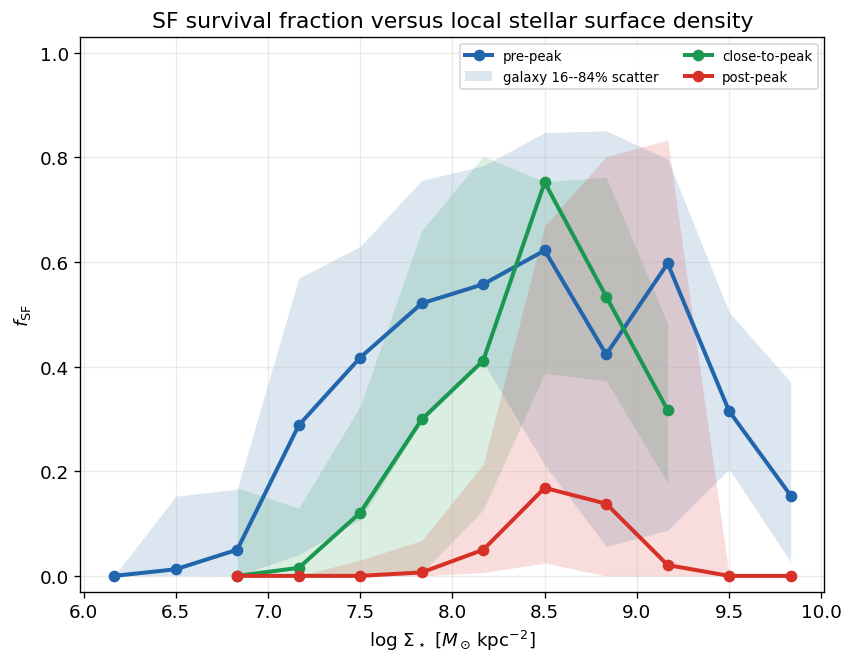

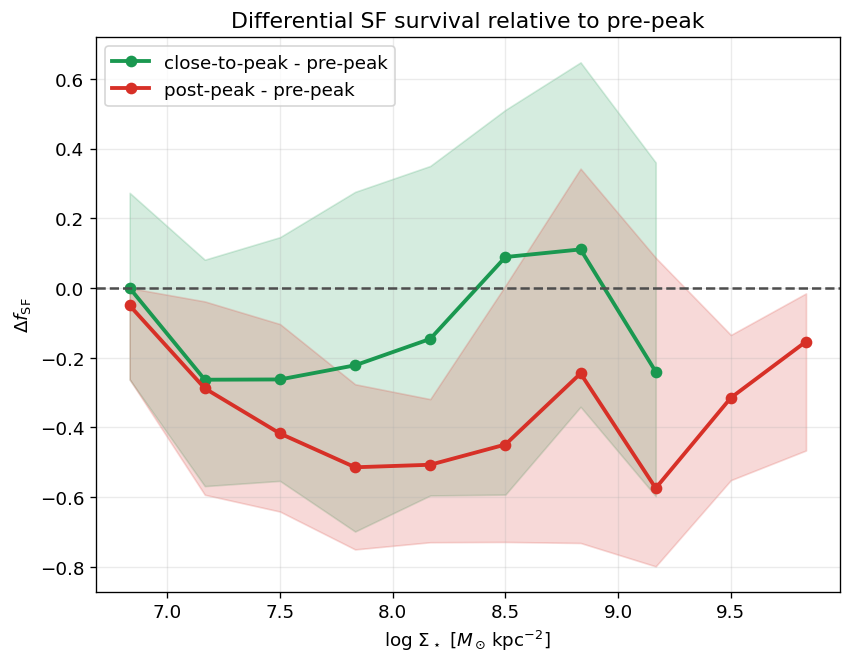

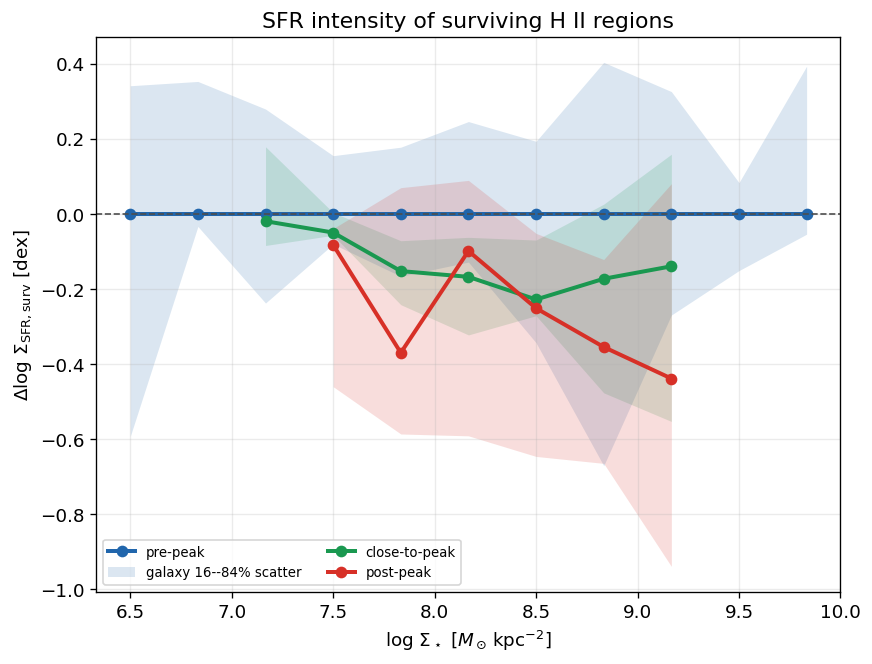

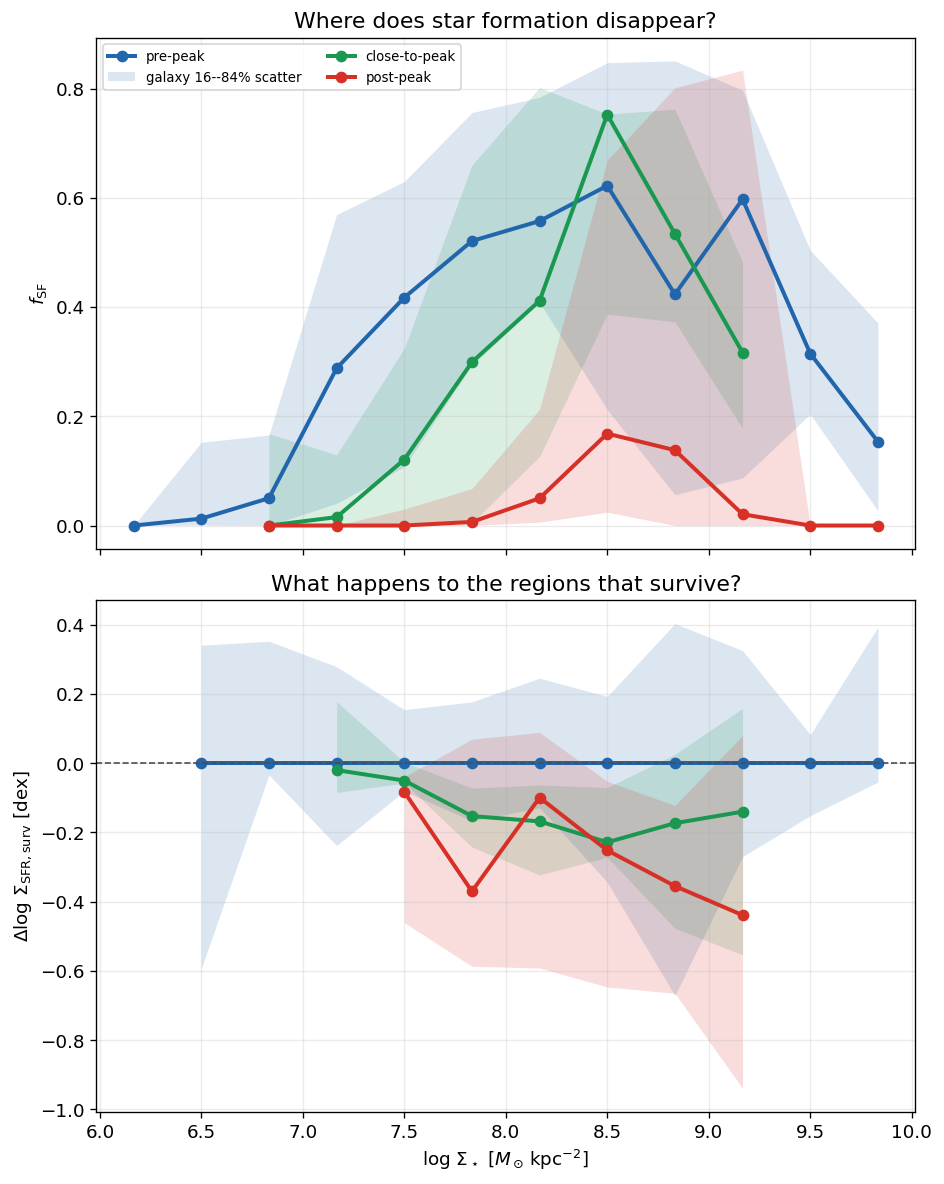

In [6]:
fsf_summary = stage_summary(by_sigma, "f_SF", "sigma_bin")
surv_summary = stage_summary(by_sigma, "surv_deltaSFR", "sigma_bin")

fig, ax = plt.subplots(figsize=(8, 6))
plot_stage_summary(ax, fsf_summary, sigma_lookup, ylabel=r"$f_{\rm SF}$",
                   title="SF survival fraction versus local stellar surface density")
ax.set_xlabel(r"$\log\,\Sigma_\star\ [M_\odot\,\mathrm{kpc}^{-2}]$")
ax.set_ylim(-0.03, 1.03); ax.legend(fontsize=8, ncol=2)
save_figure(fig, "Fig_Q1_01_fSF_vs_SigmaStar"); plt.show()

fsf_diffs = pd.concat([
    bootstrap_stage_difference(by_sigma, "f_SF", "sigma_bin", "close-to-peak", "pre-peak"),
    bootstrap_stage_difference(by_sigma, "f_SF", "sigma_bin", "post-peak", "pre-peak"),
], ignore_index=True)
fig, ax = plt.subplots(figsize=(8, 6))
for comp, color in [("close-to-peak_minus_pre-peak", STAGE_COLORS["close-to-peak"]),
                    ("post-peak_minus_pre-peak", STAGE_COLORS["post-peak"])]:
    d = fsf_diffs.loc[fsf_diffs.comparison.eq(comp)]
    x = d.sigma_bin.map(sigma_lookup)
    ax.plot(x, d.median_difference, marker="o", color=color, lw=2.3, label=comp.replace("_minus_", " - "))
    ax.fill_between(x, d.p2p5, d.p97p5, color=color, alpha=0.18)
ax.axhline(0, color="0.3", ls="--"); ax.grid(alpha=0.25)
ax.set(xlabel=r"$\log\,\Sigma_\star\ [M_\odot\,\mathrm{kpc}^{-2}]$", ylabel=r"$\Delta f_{\rm SF}$",
       title="Differential SF survival relative to pre-peak")
ax.legend(); save_figure(fig, "Fig_Q1_02_delta_fSF_vs_SigmaStar"); plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
plot_stage_summary(ax, surv_summary, sigma_lookup,
                   ylabel=r"$\Delta\log\,\Sigma_{\rm SFR,surv}$ [dex]",
                   title="SFR intensity of surviving H II regions", zero=True)
ax.set_xlabel(r"$\log\,\Sigma_\star\ [M_\odot\,\mathrm{kpc}^{-2}]$")
ax.legend(fontsize=8, ncol=2)
save_figure(fig, "Fig_Q1_03_surviving_deltaSFR_vs_SigmaStar"); plt.show()

fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharex=True)
plot_stage_summary(axes[0], fsf_summary, sigma_lookup, ylabel=r"$f_{\rm SF}$",
                   title="Where does star formation disappear?")
plot_stage_summary(axes[1], surv_summary, sigma_lookup,
                   ylabel=r"$\Delta\log\,\Sigma_{\rm SFR,surv}$ [dex]",
                   title="What happens to the regions that survive?", zero=True)
axes[1].set_xlabel(r"$\log\,\Sigma_\star\ [M_\odot\,\mathrm{kpc}^{-2}]$")
axes[0].legend(fontsize=8, ncol=2); fig.tight_layout()
save_figure(fig, "Fig_Q1_04_survival_and_intensity"); plt.show()


### Figure interpretation

1. **SF survival fraction versus local stellar surface density.** The pre-peak and close-to-peak medians rise toward intermediate-to-high $\Sigma_\star$, whereas the post-peak median remains much lower across nearly all supported bins. The broad shaded ranges show substantial galaxy-to-galaxy diversity, but the systematic post-peak displacement points to a loss of star-forming area after peak ram pressure.
2. **Differential SF survival relative to pre-peak.** The post-peak minus pre-peak curve is negative throughout the supported range; the final bootstrap diagnostic identifies robust negative differences at bin centres 7.17, 7.50, 7.83, 8.17, 9.50, and 9.83. Close-to-peak differences are smaller and change sign, so the strongest transformation is associated with the post-peak stage.
3. **SFR intensity of surviving H II regions.** Close-to-peak and post-peak medians are generally below the pre-peak reference at intermediate and high $\Sigma_\star$, but their galaxy-scatter bands are wide. No post-peak minus pre-peak survivor-intensity bin has a 95% bootstrap interval wholly below zero, so the present data do not establish suppression of the surviving regions as securely as disappearance of star-forming regions.
4. **Joint survival and survivor-intensity view.** The upper panel carries the stronger signal: fewer regions remain star forming after peak pressure. The lower panel allows additional dimming among survivors, especially at high $\Sigma_\star$, but the appropriate first-order conclusion is disappearance-dominated transformation with possible, not yet decisive, suppression of survivors.


## 7. Full footprint versus within one effective radius

The one-$R_e$ analysis does not replace the full footprint. It tests whether stage differences weaken after excluding the outer disc.


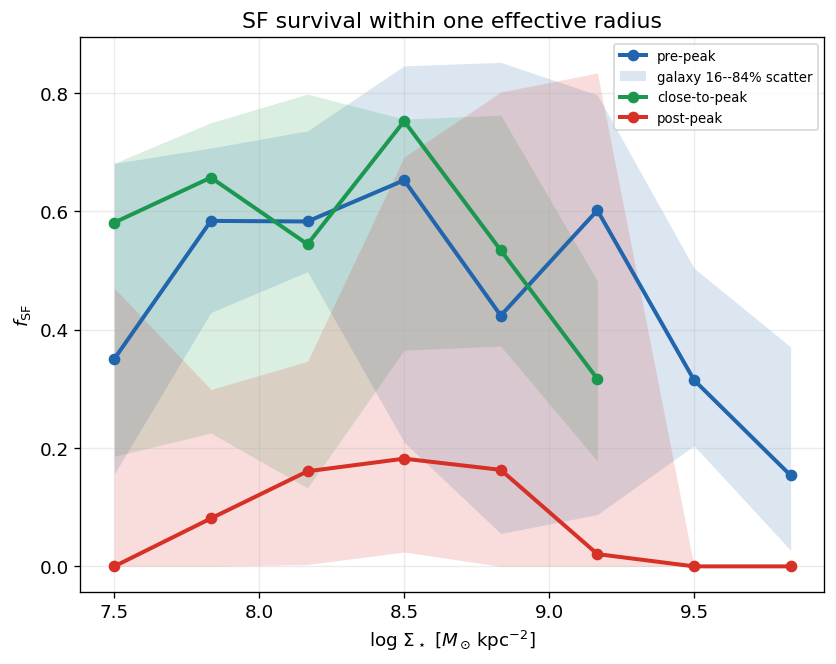

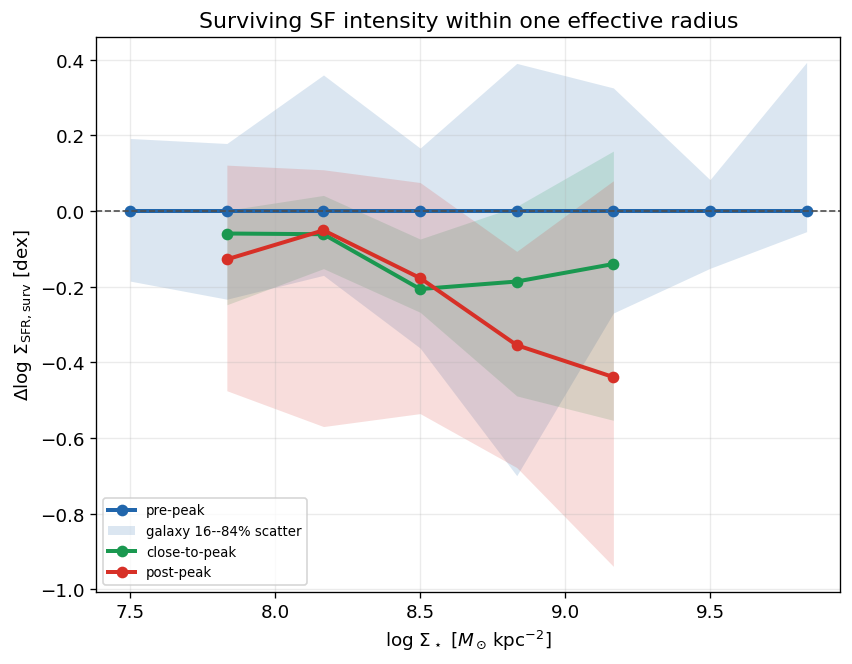

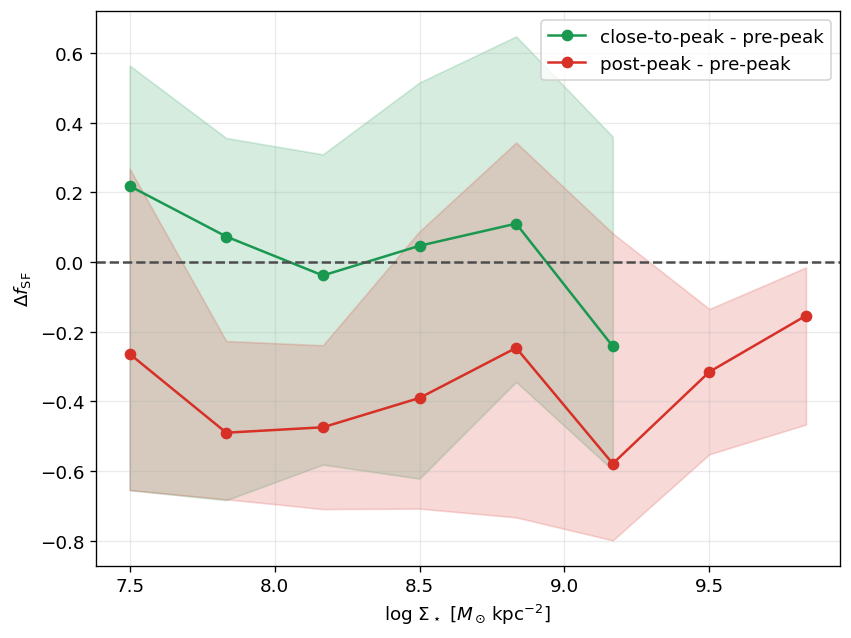

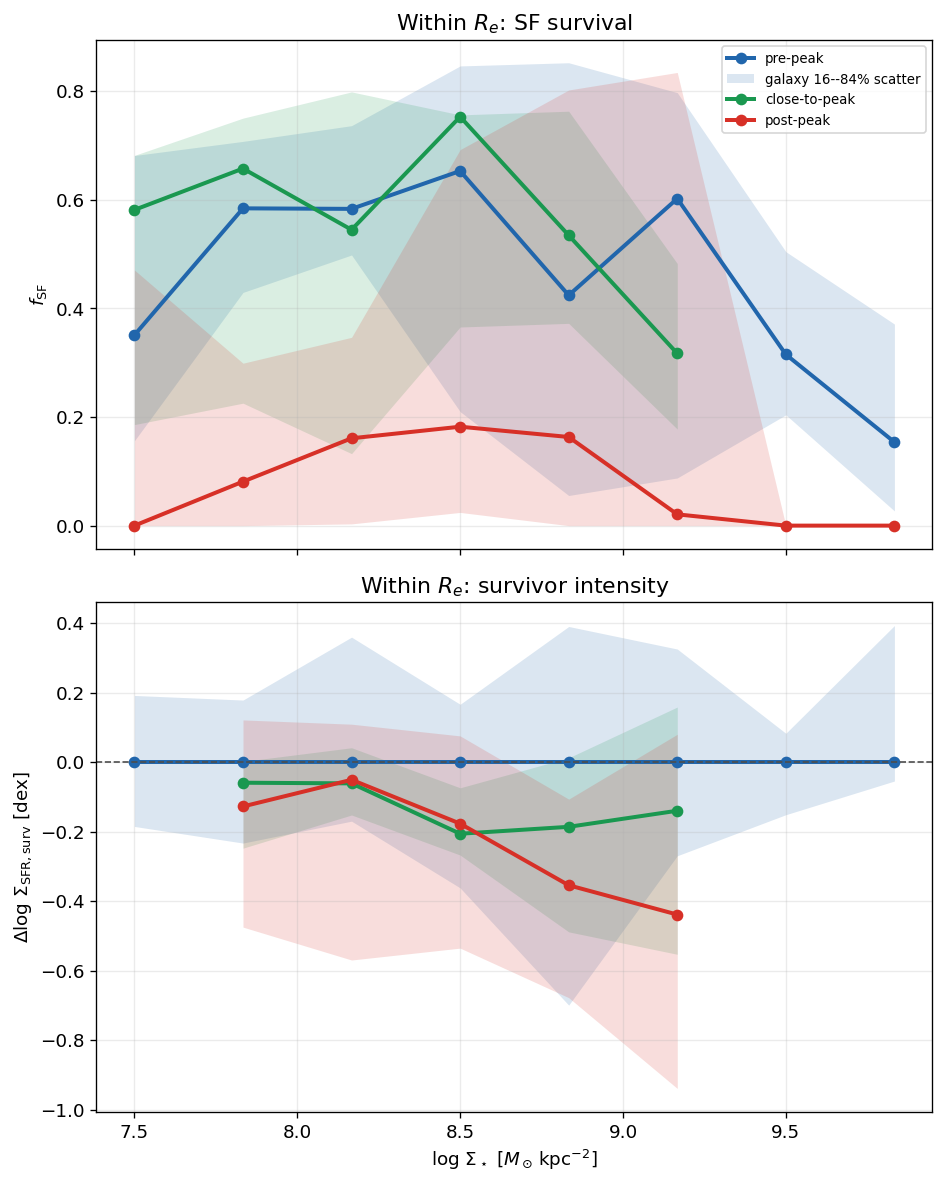

In [7]:
fsf_summary_re = stage_summary(by_sigma_within, "f_SF", "sigma_bin")
surv_summary_re = stage_summary(by_sigma_within, "surv_deltaSFR", "sigma_bin")
fsf_diffs_re = pd.concat([
    bootstrap_stage_difference(by_sigma_within, "f_SF", "sigma_bin", "close-to-peak", "pre-peak"),
    bootstrap_stage_difference(by_sigma_within, "f_SF", "sigma_bin", "post-peak", "pre-peak"),
], ignore_index=True)

for stem, summary, ylabel, title, zero in [
    ("Fig_Q1_01_fSF_vs_SigmaStar_within_Re", fsf_summary_re, r"$f_{\rm SF}$",
     r"SF survival within one effective radius", False),
    ("Fig_Q1_03_surviving_deltaSFR_vs_SigmaStar_within_Re", surv_summary_re,
     r"$\Delta\log\,\Sigma_{\rm SFR,surv}$ [dex]",
     r"Surviving SF intensity within one effective radius", True),
]:
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_stage_summary(ax, summary, sigma_lookup, ylabel=ylabel, title=title, zero=zero)
    ax.set_xlabel(r"$\log\,\Sigma_\star\ [M_\odot\,\mathrm{kpc}^{-2}]$"); ax.legend(fontsize=8)
    save_figure(fig, stem); plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for comp, color in [("close-to-peak_minus_pre-peak", STAGE_COLORS["close-to-peak"]),
                    ("post-peak_minus_pre-peak", STAGE_COLORS["post-peak"])]:
    d = fsf_diffs_re.loc[fsf_diffs_re.comparison.eq(comp)]
    x = d.sigma_bin.map(sigma_lookup)
    ax.plot(x, d.median_difference, marker="o", color=color, label=comp.replace("_minus_", " - "))
    ax.fill_between(x, d.p2p5, d.p97p5, color=color, alpha=.18)
ax.axhline(0, color=".3", ls="--"); ax.grid(alpha=.25)
ax.set(xlabel=r"$\log\,\Sigma_\star\ [M_\odot\,\mathrm{kpc}^{-2}]$", ylabel=r"$\Delta f_{\rm SF}$")
ax.legend(); save_figure(fig, "Fig_Q1_02_delta_fSF_vs_SigmaStar_within_Re"); plt.show()

fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharex=True)
plot_stage_summary(axes[0], fsf_summary_re, sigma_lookup, ylabel=r"$f_{\rm SF}$", title=r"Within $R_e$: SF survival")
plot_stage_summary(axes[1], surv_summary_re, sigma_lookup, ylabel=r"$\Delta\log\,\Sigma_{\rm SFR,surv}$ [dex]",
                   title=r"Within $R_e$: survivor intensity", zero=True)
axes[1].set_xlabel(r"$\log\,\Sigma_\star\ [M_\odot\,\mathrm{kpc}^{-2}]$"); axes[0].legend(fontsize=8)
fig.tight_layout(); save_figure(fig, "Fig_Q1_04_survival_and_intensity_within_Re"); plt.show()


### Figure interpretation

1. **SF survival within one effective radius.** Restricting the footprint to $R\leq R_e$ does not remove the strong post-peak deficit: post-peak medians stay well below the pre-peak and close-to-peak tracks across the supported $\Sigma_\star$ range. The effect is therefore not produced solely by adding the outermost disc to the full-footprint measurement.
2. **Surviving SF intensity within one effective radius.** Post-peak medians become increasingly negative toward higher $\Sigma_\star$, while the close-to-peak medians show a milder offset. The shaded galaxy scatter remains broad, so this is evidence for a possible intensity change rather than a secure population-wide detection.
3. **Within-$R_e$ differential survival.** The post-peak minus pre-peak contrast remains negative in every displayed bin and is typically about $-0.25$ to $-0.6$. Close-to-peak differences stay near zero compared with their inter-galaxy scatter. This reinforces the interpretation that the main transition occurs after peak pressure.
4. **Combined within-$R_e$ view.** The survival deficit persists in the inner footprint, while survivor-intensity offsets are less certain. Taken together with the full-footprint result, the transformation is not exclusively an outside-edge truncation signal, although radial coverage and the two-dimensional test below are still needed before assigning an independent $\Sigma_\star$ effect.


## 8. Radial counterpart and coverage control

Radial profiles quantify the conventional outside-in view. Coverage is the valid MUSE area divided by the geometrically available area on the mapped WCS grid in each annulus; bins with weak galaxy support must not drive interpretation.


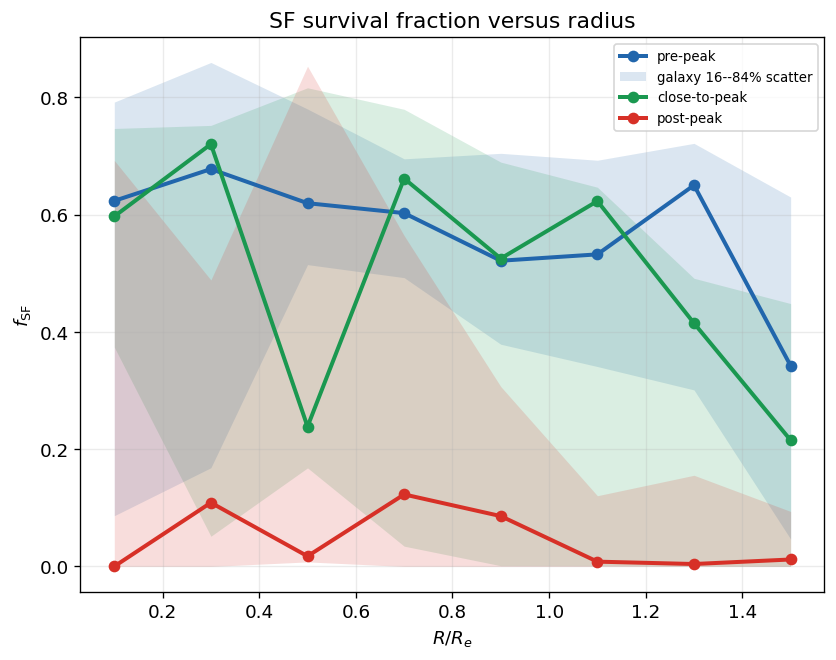

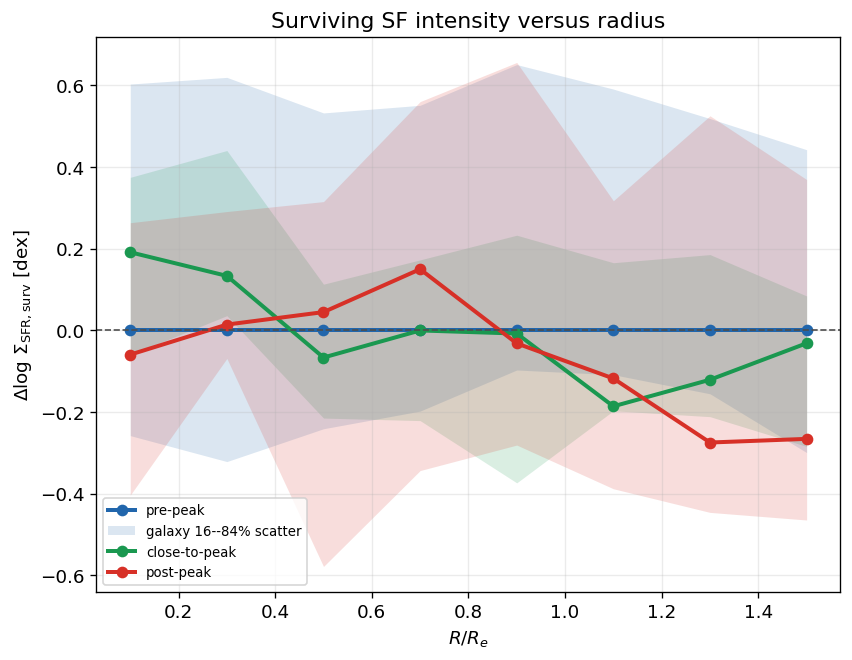

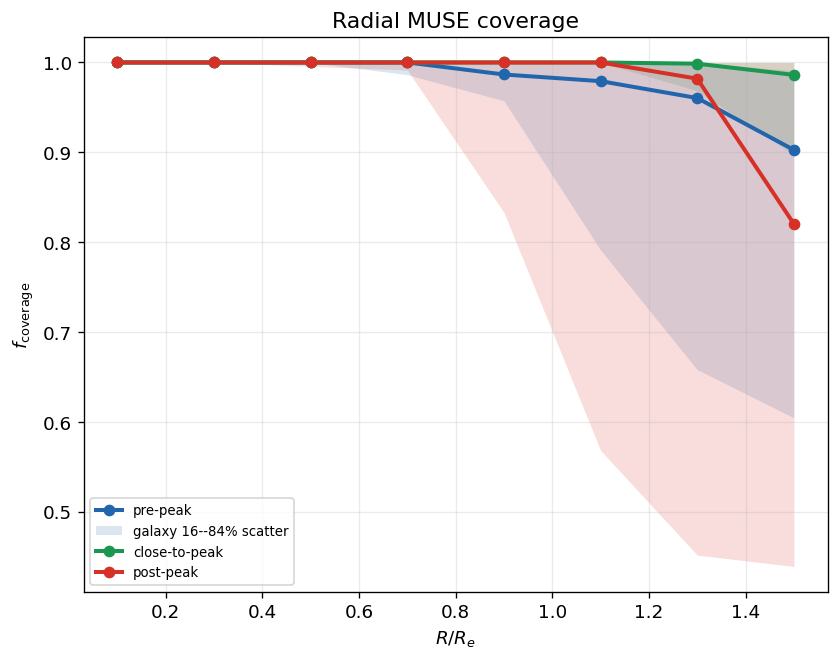

In [8]:
radius_lookup = dict(enumerate((R_EDGES[:-1] + R_EDGES[1:]) / 2))
radial_fsf_summary = stage_summary(by_radius, "f_SF", "radius_bin")
radial_surv = by_radius.copy()
radial_ref = (radial_surv.loc[radial_surv.stage.eq("pre-peak")]
              .groupby("radius_bin").surv_logSigmaSFR_median.median().rename("prepeak_reference"))
radial_surv = radial_surv.merge(radial_ref, on="radius_bin", how="left")
radial_surv["surv_deltaSFR"] = radial_surv.surv_logSigmaSFR_median - radial_surv.prepeak_reference
radial_surv_summary = stage_summary(radial_surv, "surv_deltaSFR", "radius_bin")
coverage_summary = stage_summary(by_radius, "f_coverage", "radius_bin")
save_table(pd.concat([
    radial_fsf_summary.assign(metric="f_SF"), radial_surv_summary.assign(metric="surv_deltaSFR"),
    coverage_summary.assign(metric="f_coverage")], ignore_index=True), "Q1_stage_summary_by_radius.csv")

for stem, summary, ylabel, title, zero in [
    ("Fig_Q1_05_fSF_vs_radius", radial_fsf_summary, r"$f_{\rm SF}$",
     "SF survival fraction versus radius", False),
    ("Fig_Q1_06_surviving_deltaSFR_vs_radius", radial_surv_summary,
     r"$\Delta\log\,\Sigma_{\rm SFR,surv}$ [dex]",
     "Surviving SF intensity versus radius", True),
    ("Fig_Q1_07_radial_coverage", coverage_summary, r"$f_{\rm coverage}$",
     "Radial MUSE coverage", False),
]:
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_stage_summary(ax, summary, radius_lookup, ylabel=ylabel, title=title, zero=zero)
    ax.set_xlabel(r"$R/R_e$"); ax.legend(fontsize=8); save_figure(fig, stem); plt.show()


### Figure interpretation

1. **SF survival fraction versus radius.** Post-peak galaxies have very low median $f_{\rm SF}$ at essentially every sampled radius, including inside $R_e$, while the pre-peak median remains near $0.5$--$0.7$ through most of the covered disc. The close-to-peak track is more irregular, consistent with its smaller sample and strong galaxy-to-galaxy variation.
2. **Surviving SF intensity versus radius.** Median offsets fluctuate around zero at small radius and trend negative for post-peak galaxies outside roughly $R_e$. The shaded ranges overlap zero broadly, so the radial intensity pattern is not a robust standalone detection.
3. **Radial MUSE coverage.** Median coverage is effectively complete through about $R/R_e\simeq1.1$ and remains high near $1.3R_e$. At $1.5R_e$ the post-peak median falls to about 0.82 and its scatter becomes large; conclusions in the outermost bin should therefore be treated as more coverage-sensitive than the inner-disc result.


## 9. Does $\Sigma_\star$ add information beyond radius?

Each 2D cell is first measured within each galaxy. The stage map is then the median of galaxy values, and unsupported cells are masked. The support panels show the number of independent galaxies. This binned galaxy-level result is required; no pixel-level significance is used.


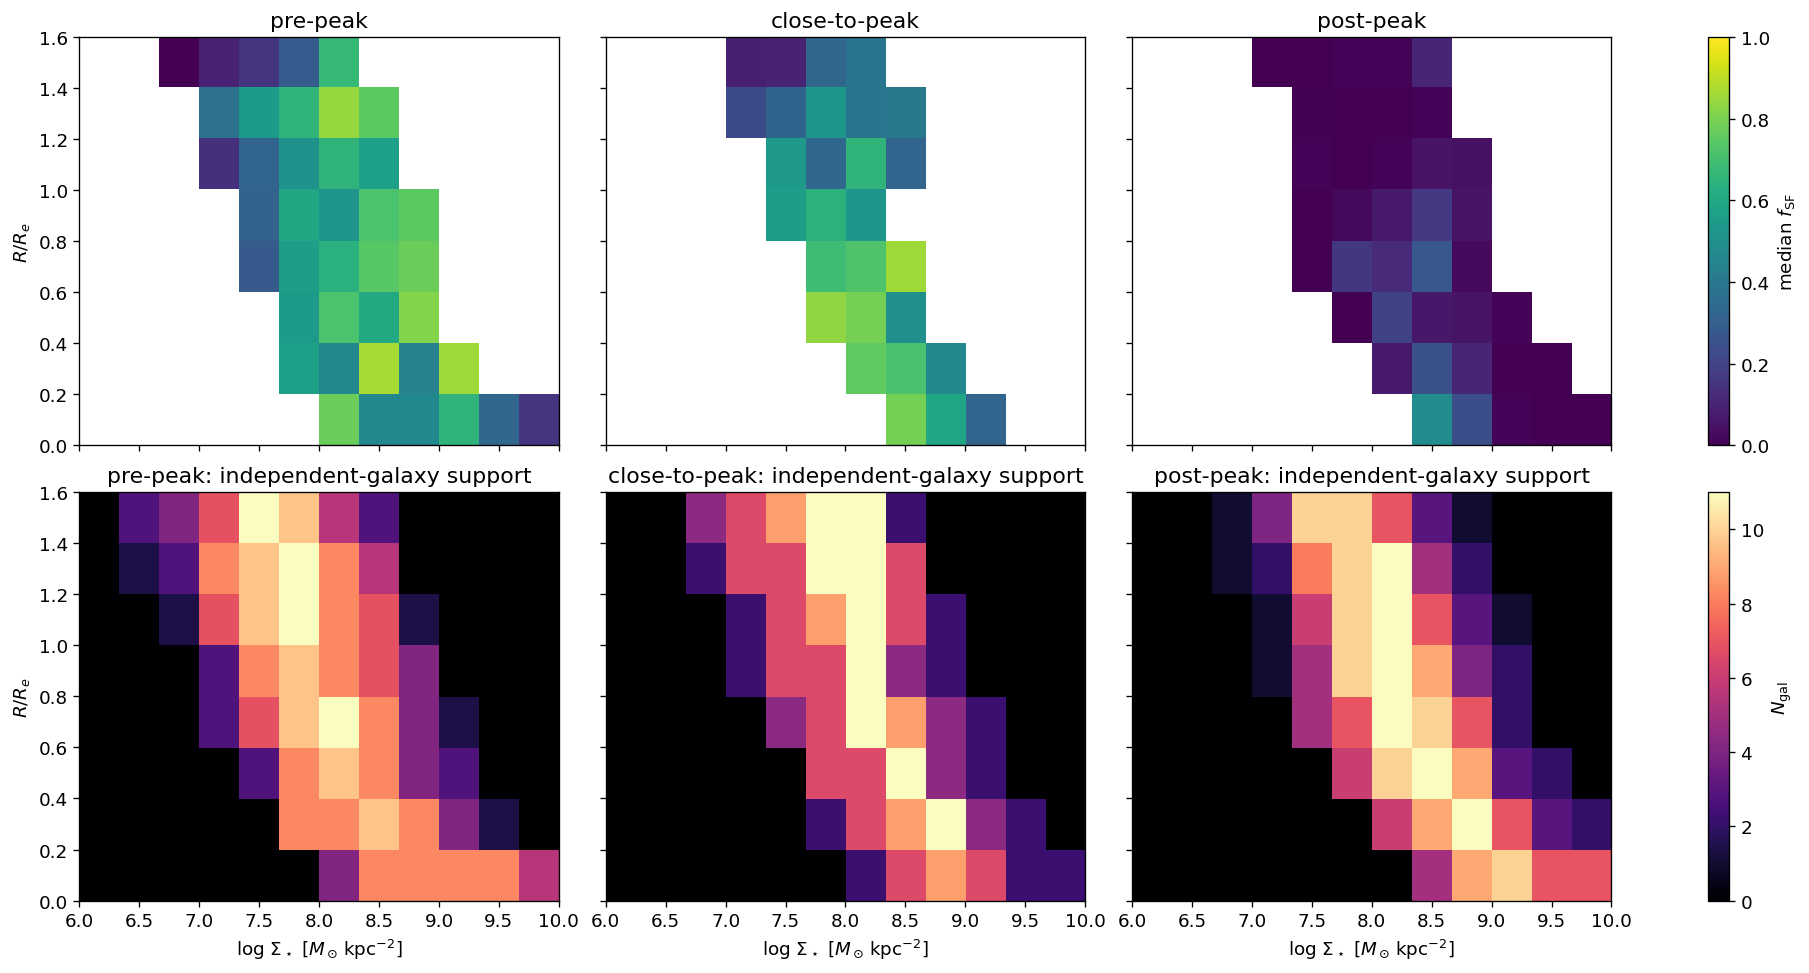

In [9]:
grid_stage_rows = []
for (stage, sb, rb), group in by_2d.groupby(["stage", "sigma_bin", "radius_bin"]):
    values = group.f_SF.dropna().to_numpy()
    grid_stage_rows.append({"stage": stage, "sigma_bin": sb, "radius_bin": rb,
                            "Ngal": len(values), "median_f_SF": np.median(values) if len(values) >= MIN_GALAXIES_PER_2D_CELL else np.nan})
grid_stage = pd.DataFrame(grid_stage_rows)
save_table(grid_stage, "Q1_fSF_2D_SigmaStar_radius_stage.csv")

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True, constrained_layout=True)
for col, stage in enumerate(STAGE_ORDER):
    g = grid_stage.loc[grid_stage.stage.eq(stage)]
    median = g.pivot(index="radius_bin", columns="sigma_bin", values="median_f_SF").reindex(index=range(len(R_EDGES)-1), columns=range(N_SIGMA_BINS))
    support = g.pivot(index="radius_bin", columns="sigma_bin", values="Ngal").reindex(index=range(len(R_EDGES)-1), columns=range(N_SIGMA_BINS))
    im = axes[0, col].imshow(median, origin="lower", aspect="auto", vmin=0, vmax=1,
                             extent=[sigma_edges[0], sigma_edges[-1], R_EDGES[0], R_EDGES[-1]], cmap="viridis")
    ims = axes[1, col].imshow(support, origin="lower", aspect="auto", vmin=0,
                              extent=[sigma_edges[0], sigma_edges[-1], R_EDGES[0], R_EDGES[-1]], cmap="magma")
    axes[0, col].set_title(stage); axes[1, col].set_title(f"{stage}: independent-galaxy support")
for ax in axes[-1]: ax.set_xlabel(r"$\log\,\Sigma_\star\ [M_\odot\,\mathrm{kpc}^{-2}]$")
for ax in axes[:, 0]: ax.set_ylabel(r"$R/R_e$")
fig.colorbar(im, ax=axes[0], label=r"median $f_{\rm SF}$"); fig.colorbar(ims, ax=axes[1], label=r"$N_{\rm gal}$")
save_figure(fig, "Fig_Q1_08_fSF_2D_SigmaStar_radius"); plt.show()


### Figure interpretation

**Two-dimensional $\Sigma_\star$--radius view.** Pre-peak and close-to-peak galaxies retain moderate-to-high median $f_{\rm SF}$ over much of the well-populated grid, whereas post-peak values are low across both radius and $\Sigma_\star$. The support panels show that the central grid is constrained by the most galaxies, while edge cells often have only a few independent systems. The persistence of stage structure within matched grid cells suggests that radius alone does not describe the transformation, but the sparse edge cells and covariance between radius and $\Sigma_\star$ require conservative, non-causal language.


## 10. Global stellar-mass confounding check

The primary sample is not cut at $\log M_\star>9.5$. Instead, the common observed mass support is determined without optimising significance, and the central measurements are repeated inside that overlap.


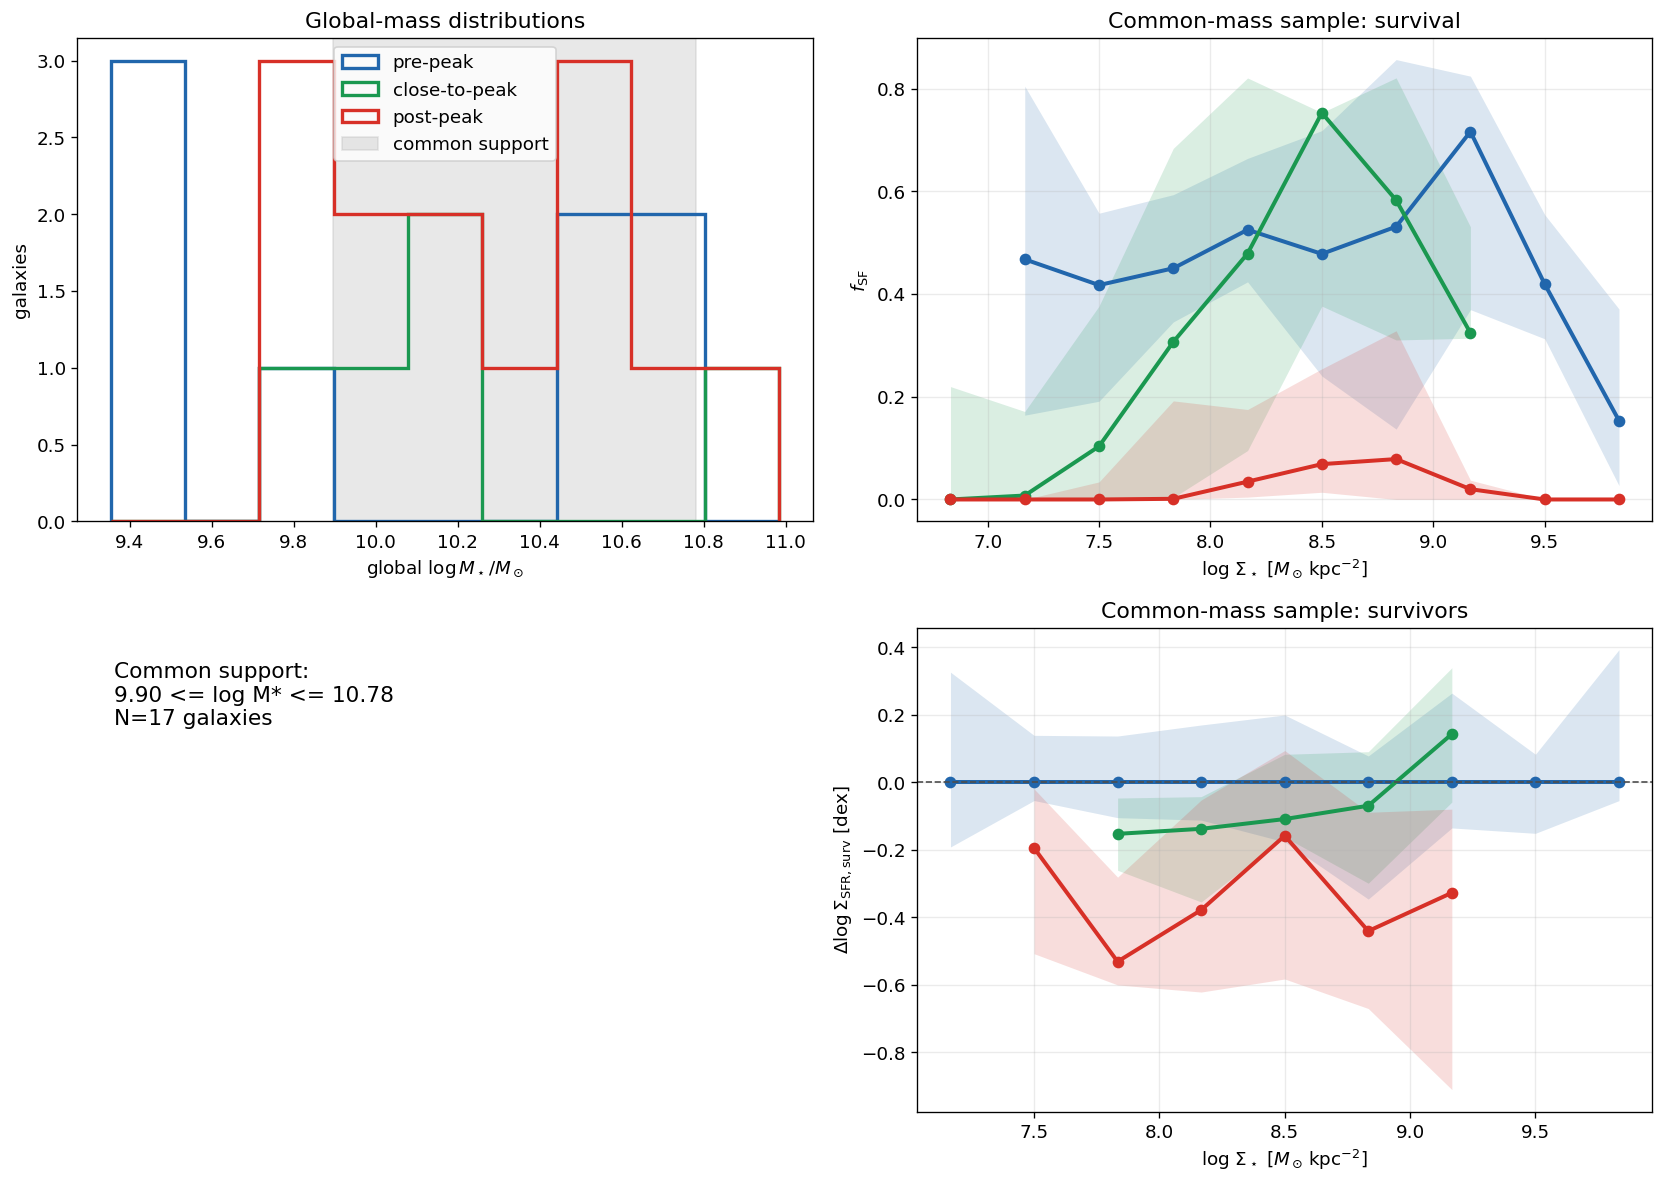

In [10]:
stage_mass_limits = primary.groupby("stage").logMstar_global.agg(["min", "max"]).reindex(STAGE_ORDER)
common_mass_lo = stage_mass_limits["min"].max()
common_mass_hi = stage_mass_limits["max"].min()
if common_mass_lo >= common_mass_hi:
    raise RuntimeError("No common global-stellar-mass support among stages")
mass_ids = primary.loc[primary.logMstar_global.between(common_mass_lo, common_mass_hi), "GALID"]
mass_control = by_sigma.loc[by_sigma.GALID.isin(mass_ids)].copy()
mass_control = add_prepeak_reference(mass_control.drop(columns=["prepeak_reference", "surv_deltaSFR"]))
mass_fsf = stage_summary(mass_control, "f_SF", "sigma_bin")
mass_surv = stage_summary(mass_control, "surv_deltaSFR", "sigma_bin")
save_table(pd.concat([mass_fsf.assign(metric="f_SF"), mass_surv.assign(metric="surv_deltaSFR")]),
           "Q1_mass_control_summary.csv")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for stage in STAGE_ORDER:
    values = primary.loc[primary.stage.eq(stage), "logMstar_global"]
    axes[0, 0].hist(values, bins=np.linspace(primary.logMstar_global.min(), primary.logMstar_global.max(), 10),
                    histtype="step", lw=2, color=STAGE_COLORS[stage], label=stage)
axes[0, 0].axvspan(common_mass_lo, common_mass_hi, color="0.7", alpha=.3, label="common support")
axes[0, 0].set(xlabel=r"global $\log M_\star/M_\odot$", ylabel="galaxies", title="Global-mass distributions"); axes[0,0].legend()
plot_stage_summary(axes[0,1], mass_fsf, sigma_lookup, ylabel=r"$f_{\rm SF}$", title="Common-mass sample: survival")
plot_stage_summary(axes[1,1], mass_surv, sigma_lookup, ylabel=r"$\Delta\log\Sigma_{\rm SFR,surv}$ [dex]",
                   title="Common-mass sample: survivors", zero=True)
axes[1,0].axis("off"); axes[1,0].text(.05,.8, f"Common support:\n{common_mass_lo:.2f} <= log M* <= {common_mass_hi:.2f}\nN={len(mass_ids)} galaxies", fontsize=13)
for ax in (axes[0,1], axes[1,1]): ax.set_xlabel(r"$\log\,\Sigma_\star\ [M_\odot\,\mathrm{kpc}^{-2}]$")
fig.tight_layout(); save_figure(fig, "Fig_Q1_09_mass_control_robustness"); plt.show()


### Figure interpretation

**Global stellar-mass control.** The three stage distributions overlap over $9.90\leq\log(M_\star/M_\odot)\leq10.78$, giving a common-support subset of 17 galaxies. Within that subset, the post-peak survival fraction remains far below the pre-peak track, so the primary disappearance signal is not explained simply by different global-mass distributions. Post-peak survivor-intensity medians are also negative in the supported bins, but their broad galaxy scatter preserves the same uncertainty seen in the full sample.


## 11. Inclination robustness

Repeat the central two observables for fixed, pre-declared cuts of 60, 65, and 70 degrees. Do not select the cut that gives the strongest trend.


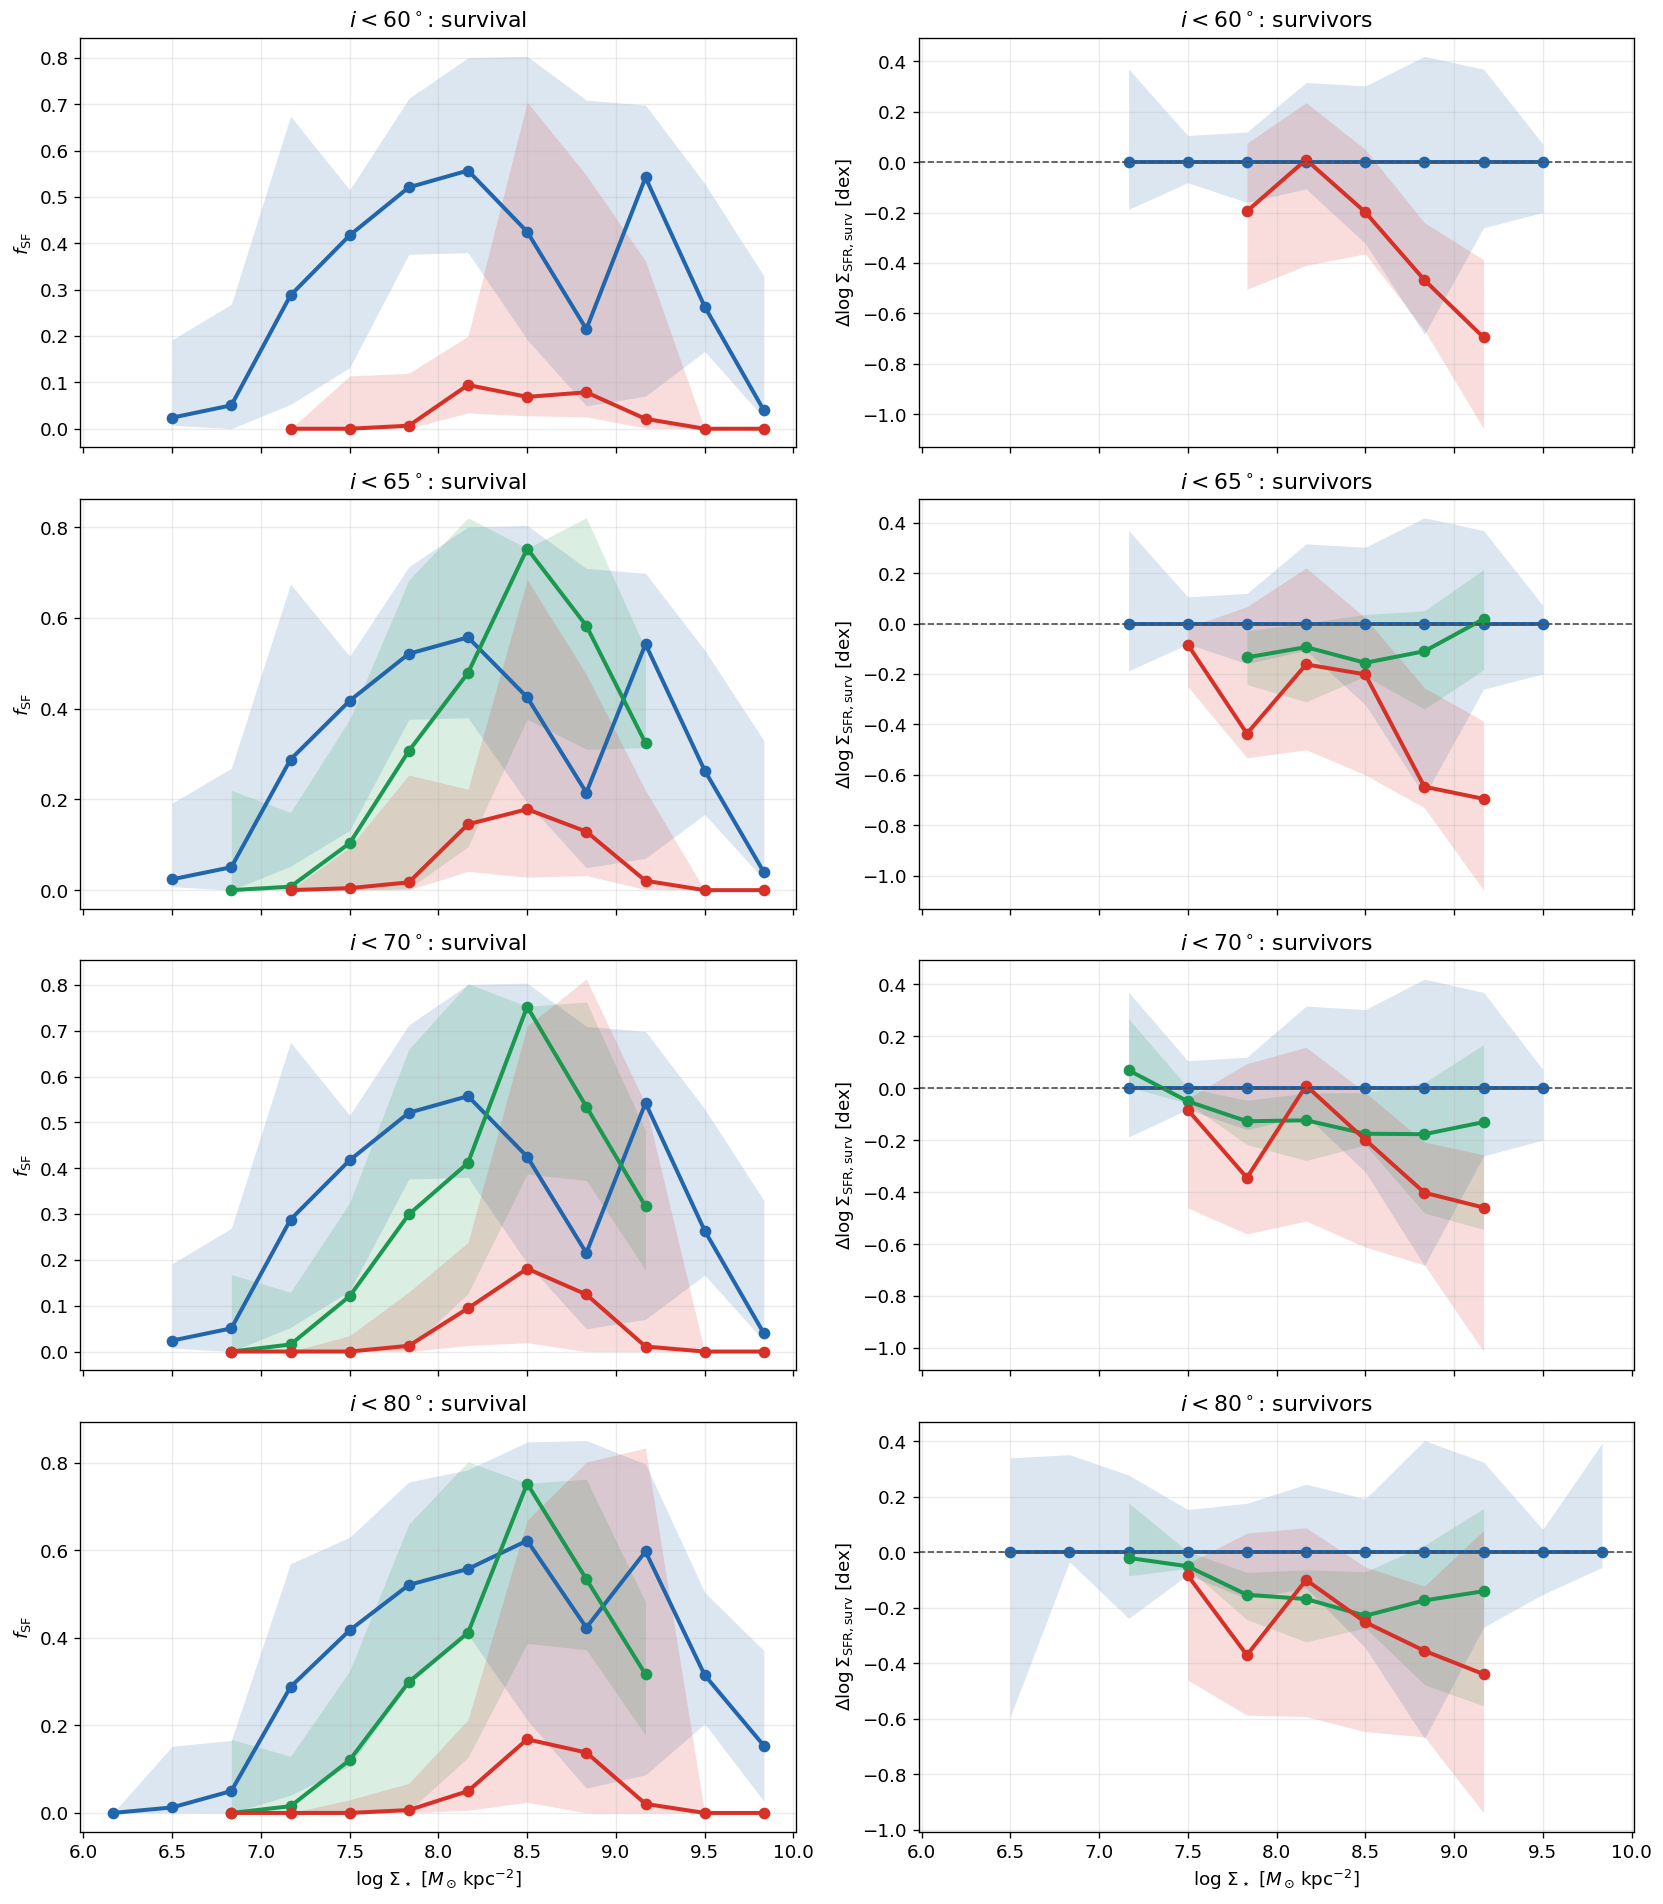

PosixPath('/Users/Igniz/Desktop/ICRAR/further/outputs/paper2_Q1_first_order_SF/tables/Q1_inclination_per_galaxy.csv')

In [11]:
inclination_outputs = []
fig, axes = plt.subplots(len(I_MAX_ROBUSTNESS), 2, figsize=(14, 4 * len(I_MAX_ROBUSTNESS)), sharex=True)
for rix, cut in enumerate(I_MAX_ROBUSTNESS):
    ids = inventory.loc[inventory.inclination.lt(cut) & inventory.GALID.isin(qc.loc[qc.QC_flag.eq("OK"), "GALID"]), "GALID"]
    subset = by_sigma.loc[by_sigma.GALID.isin(ids)].drop(columns=["prepeak_reference", "surv_deltaSFR"])
    subset = add_prepeak_reference(subset)
    a = stage_summary(subset, "f_SF", "sigma_bin")
    b = stage_summary(subset, "surv_deltaSFR", "sigma_bin")
    inclination_outputs += [a.assign(I_MAX=cut, metric="f_SF"), b.assign(I_MAX=cut, metric="surv_deltaSFR")]
    plot_stage_summary(axes[rix,0], a, sigma_lookup, ylabel=r"$f_{\rm SF}$", title=fr"$i < {cut:.0f}^\circ$: survival")
    plot_stage_summary(axes[rix,1], b, sigma_lookup, ylabel=r"$\Delta\log\Sigma_{{\rm SFR,surv}}$ [dex]",
                       title=fr"$i < {cut:.0f}^\circ$: survivors", zero=True)
save_table(pd.concat(inclination_outputs, ignore_index=True), "Q1_inclination_robustness_summary.csv")
for ax in axes[-1]: ax.set_xlabel(r"$\log\,\Sigma_\star\ [M_\odot\,\mathrm{kpc}^{-2}]$")
fig.tight_layout(); save_figure(fig, "Fig_Q1_10_inclination_robustness"); plt.show()

inclination_diag = by_sigma.groupby(["GALID", "stage", "inclination"], as_index=False).agg(
    integrated_f_SF=("N_SF", "sum"), integrated_N_valid=("N_valid", "sum"),
    median_surv_deltaSFR=("surv_deltaSFR", "median"))
inclination_diag["integrated_f_SF"] /= inclination_diag.integrated_N_valid
save_table(inclination_diag, "Q1_inclination_per_galaxy.csv")


### Figure interpretation

**Inclination robustness.** The low post-peak survival fraction persists for the useful $i<65^\circ$, $i<70^\circ$, and primary $i<80^\circ$ selections, with similar $\Sigma_\star$ dependence. The $i<60^\circ$ panel has too little three-stage support--the close-to-peak track is absent--so it should not be used as the main comparison. Survivor-intensity medians are usually negative after peak pressure, especially at high $\Sigma_\star$, but the shaded scatter remains large. Overall, relaxing the sample to $i<80^\circ$ increases coverage without creating the survival-fraction ordering.


## 12. H II versus broader H II+Composite SF selection

H II remains primary. The broader `LOGSFR_SURFACE_DENSITY_SF` selection is repeated independently and is not merged with H II. Both definitions retain the same `PROXY_EWHA > 6` Angstrom and intrinsic Halpha sigma `< 45 km/s` cuts.


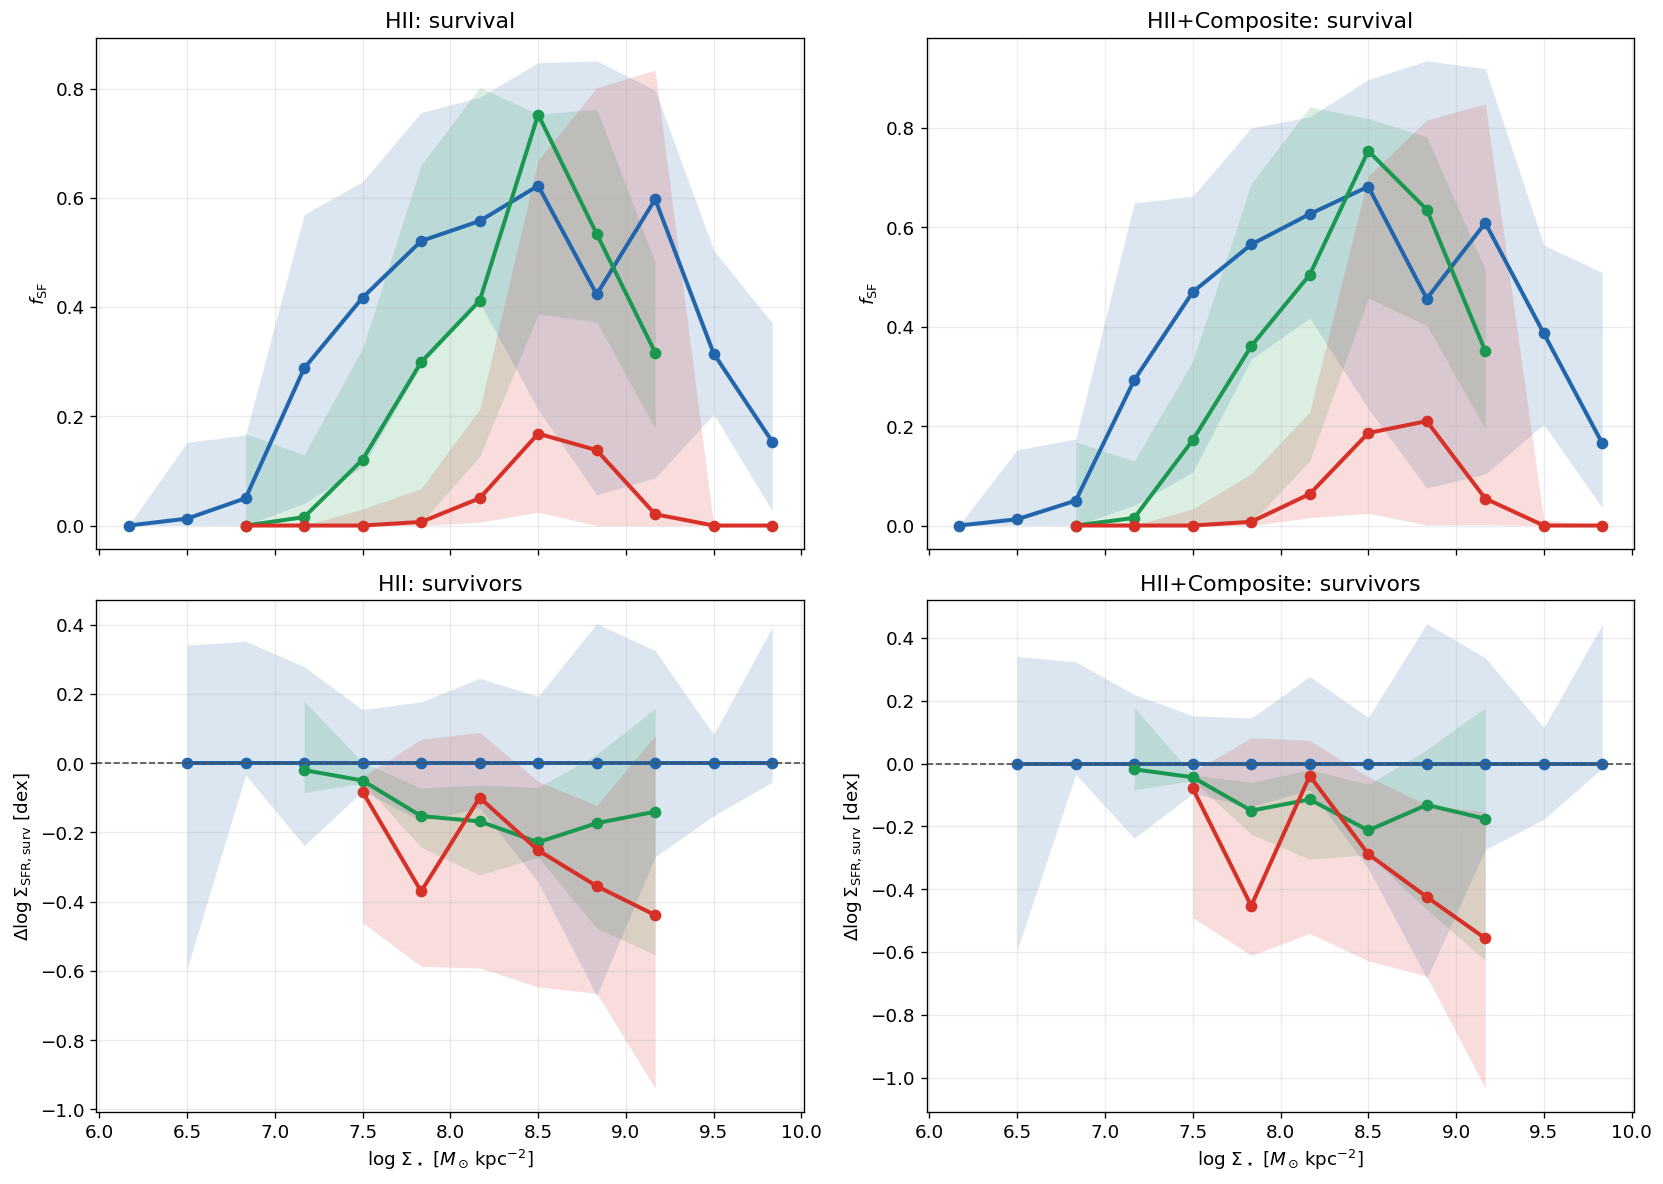

In [12]:
robust_parts = []
for row in primary.itertuples(index=False):
    robust_maps = load_galaxy_maps(row, geometry, SFR_HDU_ROBUST)
    robust_parts.append(measure_fsf_by_sigma(row, robust_maps, sigma_edges))
robust_sigma = add_prepeak_reference(pd.concat(robust_parts, ignore_index=True))
selection_outputs = []
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
for col, (label, frame) in enumerate((("HII", by_sigma), ("HII+Composite", robust_sigma))):
    a = stage_summary(frame, "f_SF", "sigma_bin")
    b = stage_summary(frame, "surv_deltaSFR", "sigma_bin")
    selection_outputs += [a.assign(selection=label, metric="f_SF"), b.assign(selection=label, metric="surv_deltaSFR")]
    plot_stage_summary(axes[0,col], a, sigma_lookup, ylabel=r"$f_{\rm SF}$", title=f"{label}: survival")
    plot_stage_summary(axes[1,col], b, sigma_lookup, ylabel=r"$\Delta\log\Sigma_{\rm SFR,surv}$ [dex]",
                       title=f"{label}: survivors", zero=True)
    axes[1,col].set_xlabel(r"$\log\,\Sigma_\star\ [M_\odot\,\mathrm{kpc}^{-2}]$")
save_table(pd.concat(selection_outputs, ignore_index=True), "Q1_HII_vs_SF_selection_summary.csv")
fig.tight_layout(); save_figure(fig, "Fig_Q1_11_HII_vs_SF_selection"); plt.show()


### Figure interpretation

**H II versus H II+Composite selection.** Including Composite-classified regions raises some survival-fraction medians, as expected from the broader numerator, but it does not change the qualitative stage ordering: post-peak galaxies remain strongly deficient relative to pre-peak galaxies. The survivor-intensity panels likewise retain generally negative post-peak offsets at intermediate and high $\Sigma_\star$. The main conclusion is therefore robust to this classification choice, while the notebook's primary definition remains the requested H II/SF map plus EW(H$\alpha$) and intrinsic-$\sigma$(H$\alpha$) cuts.


## 13. Individual-galaxy and leave-one-galaxy-out diagnostics

Individual curves reveal whether stage summaries are driven by one or two systems. Leave-one-out differences are recomputed at the galaxy level.


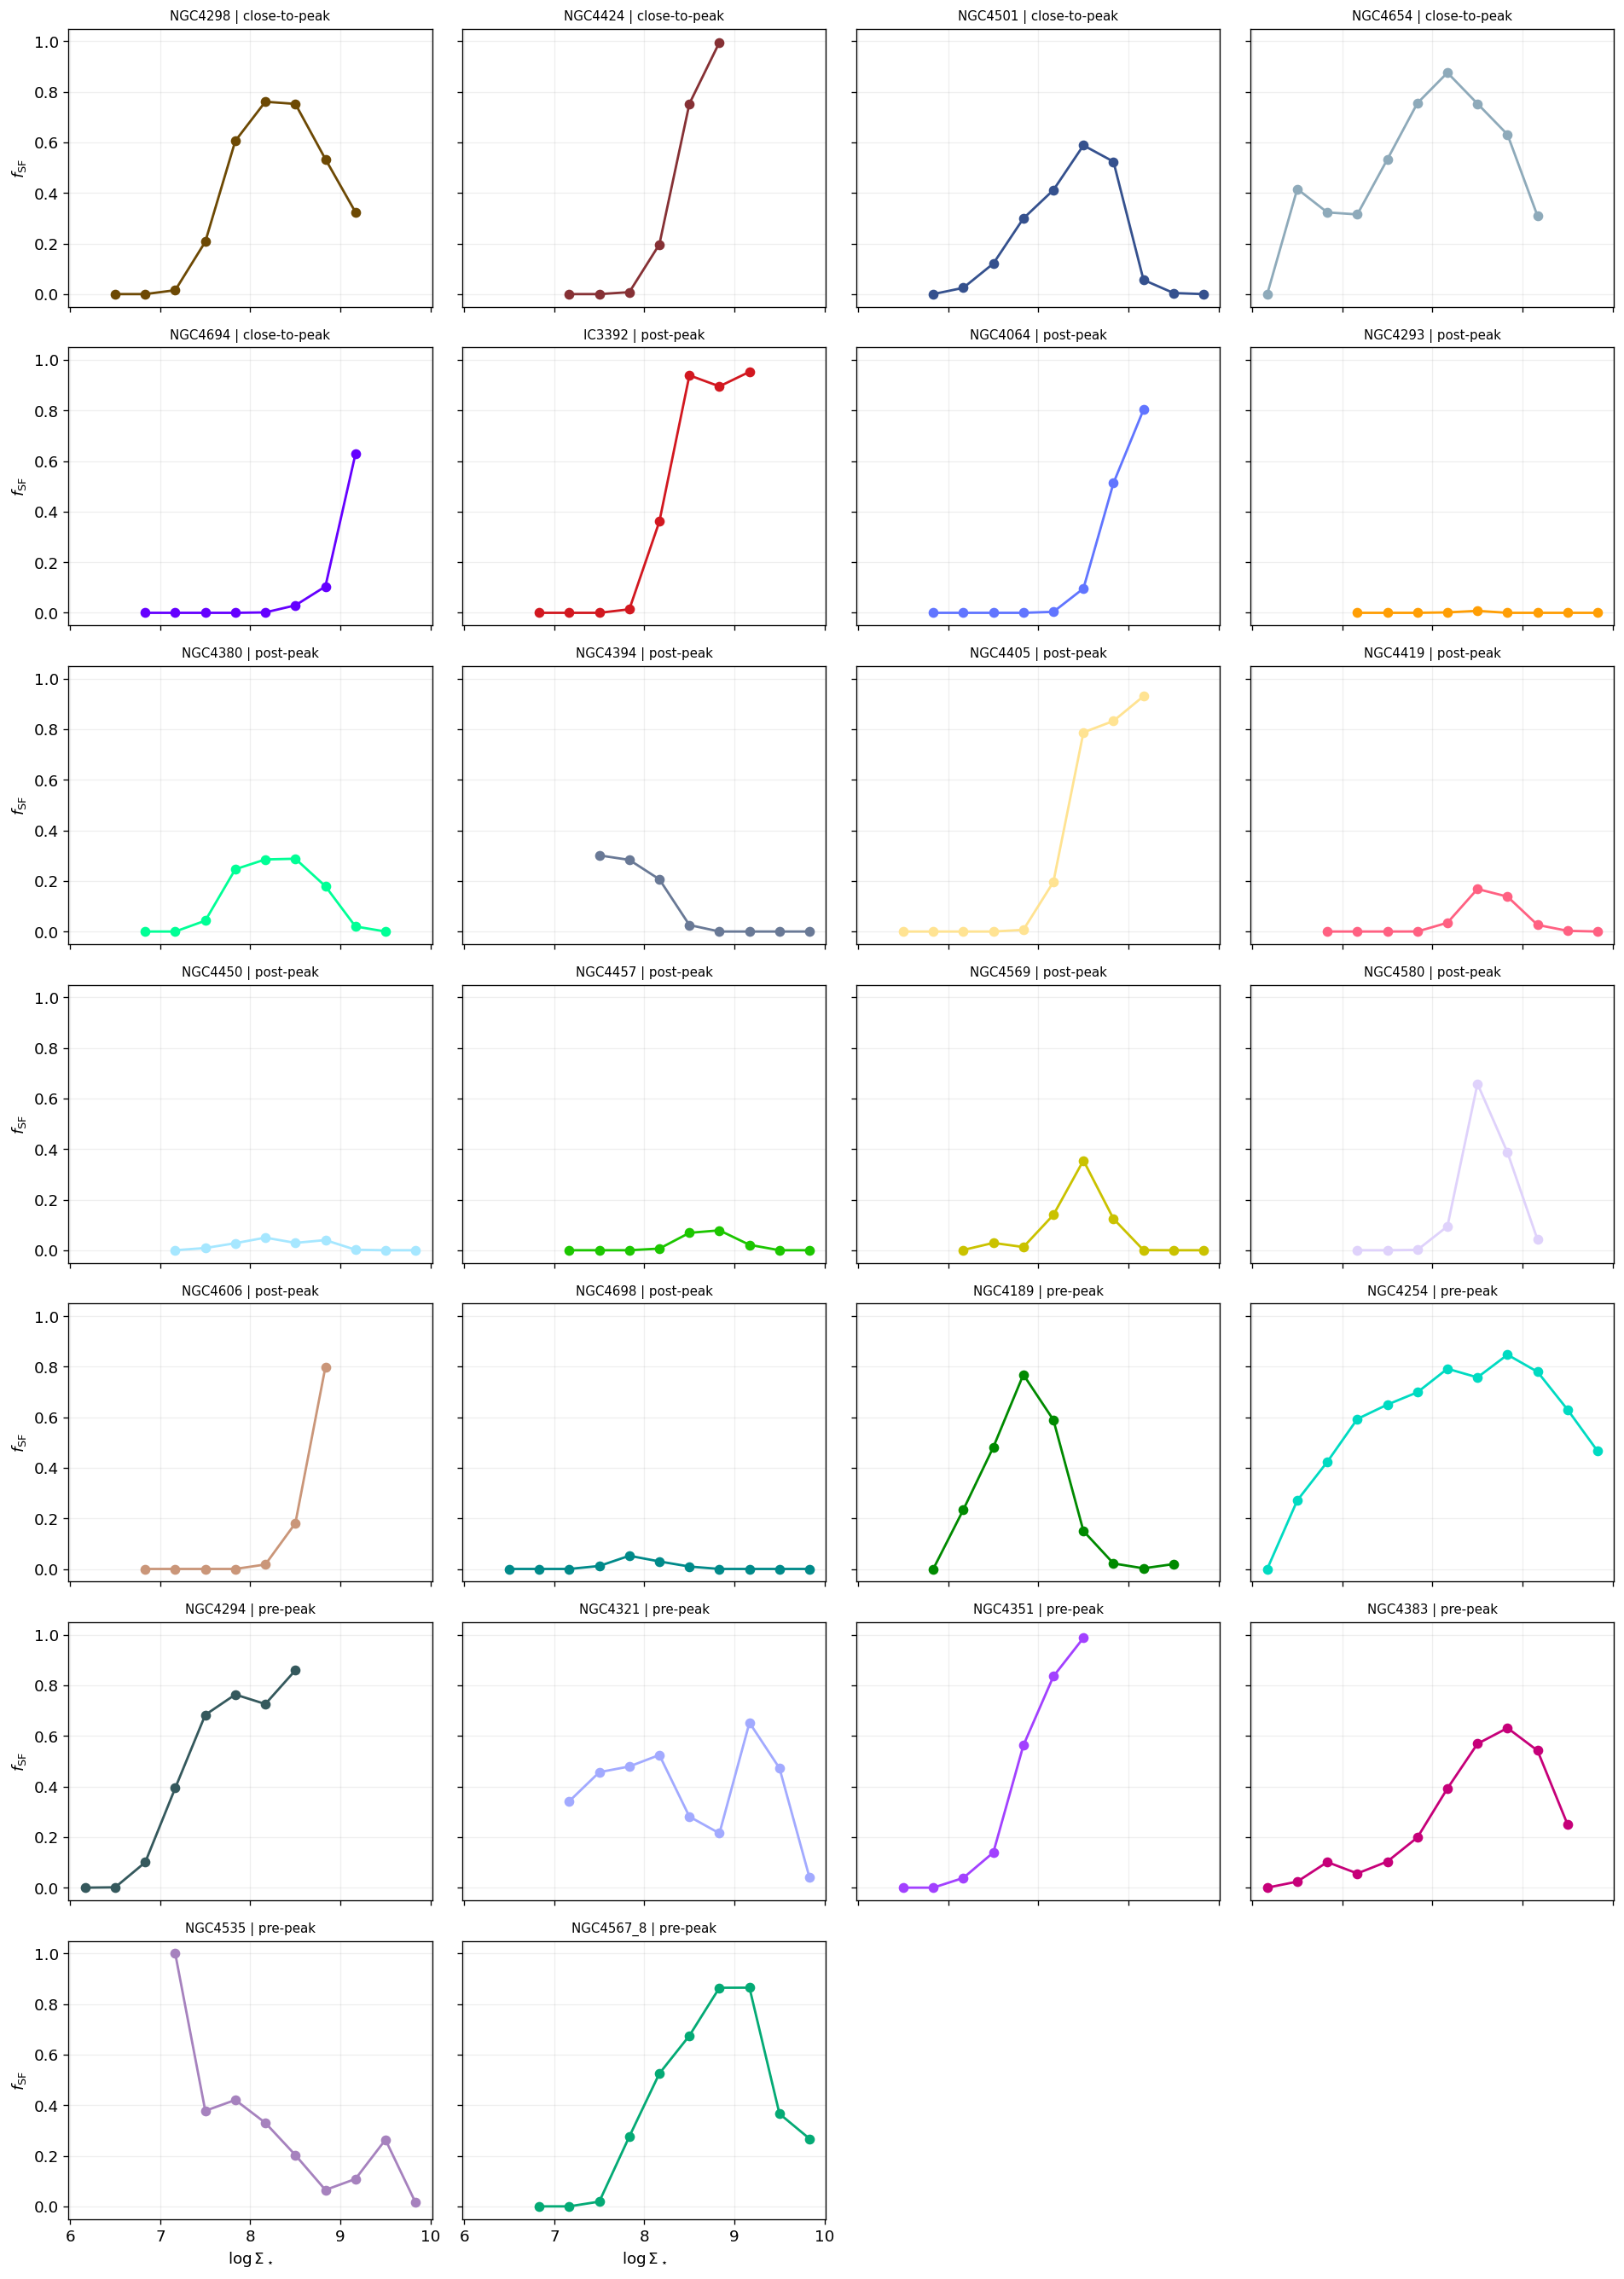

PosixPath('/Users/Igniz/Desktop/ICRAR/further/outputs/paper2_Q1_first_order_SF/tables/Q1_leave_one_out_results.csv')

In [13]:
def load_galaxy_colors(path):
    colors = {}
    for line in path.read_text().splitlines():
        fields = line.split()
        if not fields or fields[0].startswith("#") or fields[0] == "reserved":
            continue
        if fields[0] == "alias":
            colors[fields[1]] = fields[3]
        elif fields[0].isdigit():
            colors[fields[1]] = fields[3]
    return colors

galaxy_colors = load_galaxy_colors(GALAXY_COLOR_PATH)
ordered = primary.sort_values(["stage", "GALID"])
ncols = 4; nrows = math.ceil(len(ordered) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2*nrows), sharex=True, sharey=True)
for ax, row in zip(np.ravel(axes), ordered.itertuples(index=False)):
    g = by_sigma.loc[by_sigma.GALID.eq(row.GALID)].sort_values("sigma_bin")
    ax.plot(g.sigma_bin_center, g.f_SF, marker="o", lw=1.7, color=galaxy_colors.get(row.GALID, "0.3"))
    ax.set_title(f"{row.GALID} | {row.stage}", fontsize=9); ax.grid(alpha=.2); ax.set_ylim(-.05,1.05)
for ax in np.ravel(axes)[len(ordered):]: ax.axis("off")
for ax in axes[-1,:]: ax.set_xlabel(r"$\log\Sigma_\star$")
for ax in axes[:,0]: ax.set_ylabel(r"$f_{\rm SF}$")
fig.tight_layout(); save_figure(fig, "Fig_Q1_12_individual_galaxy_fSF", diagnostic=True); plt.show()

loo_rows = []
for omitted in primary.GALID:
    subset = by_sigma.loc[~by_sigma.GALID.eq(omitted)]
    for metric in ("f_SF", "surv_deltaSFR"):
        for a in ("close-to-peak", "post-peak"):
            diff = bootstrap_stage_difference(subset, metric, "sigma_bin", a, "pre-peak")
            diff["omitted_GALID"] = omitted
            loo_rows.append(diff)
loo = pd.concat(loo_rows, ignore_index=True)
save_table(loo, "Q1_leave_one_out_results.csv")


### Figure interpretation

**Individual-galaxy SF survival tracks.** The montage confirms that the stage medians do not describe every galaxy: some post-peak systems are almost entirely non-star-forming across the sampled $\Sigma_\star$ range, whereas others retain sharply peaked or even high survival fractions. Pre-peak and close-to-peak galaxies are also diverse in profile shape and amplitude. This heterogeneity justifies treating galaxies--rather than spaxels--as the independent units, displaying the galaxy-to-galaxy scatter, and retaining the leave-one-galaxy-out and whole-galaxy bootstrap checks for population-level claims.


## 14. Bootstrap comparisons and required summary table

All comparisons resample entire galaxies within stages. Report effect sizes and intervals; do not translate bootstrap fractions into exaggerated “sigma detections.”

`Q1_stage_summary_by_SigmaStar.csv` contains the required base schema
`Ngal_pre`, `Ngal_close`, `Ngal_post`, `fSF_pre`, `fSF_close`, `fSF_post`,
`delta_fSF_close_pre`, `delta_fSF_post_pre`, `surv_deltaSFR_pre`,
`surv_deltaSFR_close`, `surv_deltaSFR_post`, `delta_survSFR_close_pre`, and
`delta_survSFR_post_pre`, plus separate bootstrap-interval and probability columns.


In [14]:
stage_differences = pd.concat([
    bootstrap_stage_difference(by_sigma, metric, "sigma_bin", stage, "pre-peak")
    for metric in ("f_SF", "surv_deltaSFR")
    for stage in ("close-to-peak", "post-peak")
], ignore_index=True)
save_table(stage_differences, "Q1_stage_differences_bootstrap.csv")

def wide_metric(summary, prefix):
    keep = summary[["sigma_bin", "stage", "Ngal", "median", "boot_p2p5", "boot_p16", "boot_p84", "boot_p97p5"]].copy()
    wide = keep.pivot(index="sigma_bin", columns="stage")
    wide.columns = [f"{prefix}_{stat}_{stage.replace('-', '_')}" for stat, stage in wide.columns]
    return wide.reset_index()

summary = pd.DataFrame({"sigma_bin": range(N_SIGMA_BINS), "sigma_bin_center": sigma_centres,
                        "sigma_bin_lo": sigma_edges[:-1], "sigma_bin_hi": sigma_edges[1:]})
summary = summary.merge(wide_metric(fsf_summary, "fSF"), on="sigma_bin", how="left")
summary = summary.merge(wide_metric(surv_summary, "surv_deltaSFR"), on="sigma_bin", how="left")
for stage, alias in (("pre-peak", "pre"), ("close-to-peak", "close"), ("post-peak", "post")):
    fs = fsf_summary.loc[fsf_summary.stage.eq(stage)].set_index("sigma_bin")
    sv = surv_summary.loc[surv_summary.stage.eq(stage)].set_index("sigma_bin")
    summary[f"Ngal_{alias}"] = summary.sigma_bin.map(fs.Ngal)
    summary[f"fSF_{alias}"] = summary.sigma_bin.map(fs["median"])
    summary[f"surv_deltaSFR_{alias}"] = summary.sigma_bin.map(sv["median"])
for _, d in stage_differences.iterrows():
    comp = d.comparison.replace("-", "_")
    short_comp = "close_pre" if d.comparison.startswith("close-to-peak") else "post_pre"
    metric = "delta_fSF" if d.metric == "f_SF" else "delta_survSFR"
    mask = summary.sigma_bin.eq(d.sigma_bin)
    summary.loc[mask, f"{metric}_{short_comp}"] = d["median_difference"]
    for field in ["median_difference", "p2p5", "p16", "p84", "p97p5", "fraction_above_zero", "fraction_below_zero"]:
        summary.loc[mask, f"{metric}_{comp}_{field}"] = d[field]
save_table(summary, "Q1_stage_summary_by_SigmaStar.csv")
display(summary)


,sigma_bin,sigma_bin_center,sigma_bin_lo,sigma_bin_hi,fSF_Ngal_close_to_peak,fSF_Ngal_post_peak,fSF_Ngal_pre_peak,fSF_median_close_to_peak,fSF_median_post_peak,fSF_median_pre_peak,...,delta_survSFR_close_to_peak_minus_pre_peak_fraction_above_zero,delta_survSFR_close_to_peak_minus_pre_peak_fraction_below_zero,delta_survSFR_post_pre,delta_survSFR_post_peak_minus_pre_peak_median_difference,delta_survSFR_post_peak_minus_pre_peak_p2p5,delta_survSFR_post_peak_minus_pre_peak_p16,delta_survSFR_post_peak_minus_pre_peak_p84,delta_survSFR_post_peak_minus_pre_peak_p97p5,delta_survSFR_post_peak_minus_pre_peak_fraction_above_zero,delta_survSFR_post_peak_minus_pre_peak_fraction_below_zero
0,0,6.166667,6.000000,6.333333,1,0,3,NaN,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,6.500000,6.333333,6.666667,2,2,4,NaN,NaN,0.012637,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,6.833333,6.666667,7.000000,4,7,6,0.000000,0.000000,0.050067,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,7.166667,7.000000,7.333333,5,12,8,0.015377,0.000000,0.287946,...,0.4889,0.5111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,7.500000,7.333333,7.666667,5,13,8,0.120854,0.000000,0.417409,...,0.2461,0.7539,-0.110523,-0.110523,-0.715845,-0.349213,-0.040299,0.038300,0.0515,0.9485
5,5,7.833333,7.666667,8.000000,5,13,8,0.299221,0.006617,0.520981,...,0.0580,0.9420,-0.353624,-0.353624,-0.633870,-0.534640,-0.095678,0.101791,0.1158,0.8842
6,6,8.166667,8.000000,8.333333,5,13,8,0.411607,0.049900,0.557540,...,0.0645,0.9355,-0.137676,-0.137676,-0.611775,-0.379296,0.014263,0.116166,0.2148,0.7852
7,7,8.500000,8.333333,8.666667,5,13,8,0.752368,0.168273,0.622208,...,0.1280,0.8720,-0.222671,-0.222671,-0.541854,-0.324940,-0.071340,0.119987,0.0996,0.9004
8,8,8.833333,8.666667,9.000000,5,13,6,0.534101,0.138003,0.423279,...,0.2145,0.7855,-0.354877,-0.354877,-0.796478,-0.571005,-0.192423,0.373588,0.1079,0.8921
9,9,9.166667,9.000000,9.333333,4,12,6,0.316708,0.020695,0.597434,...,0.3539,0.6461,-0.438787,-0.438787,-1.008518,-0.726626,-0.146068,0.150335,0.0470,0.9530


## 15. End-of-notebook numerical diagnostic

The text below reports measured intervals and support. It does not automatically turn them into strong causal claims.


In [15]:
post_fsf = stage_differences.loc[
    stage_differences.metric.eq("f_SF") & stage_differences.comparison.eq("post-peak_minus_pre-peak")
].copy()
post_surv = stage_differences.loc[
    stage_differences.metric.eq("surv_deltaSFR") & stage_differences.comparison.eq("post-peak_minus_pre-peak")
].copy()
disappearance = post_fsf.loc[post_fsf.p97p5.lt(0), "sigma_bin"].map(sigma_lookup).to_list()
suppression = post_surv.loc[post_surv.p97p5.lt(0), "sigma_bin"].map(sigma_lookup).to_list()

high_supported = post_surv.dropna(subset=["p2p5", "p97p5"]).sort_values("sigma_bin").tail(1)
if high_supported.empty:
    high_statement = "No high-Sigma* bin has sufficient independent-galaxy support."
else:
    h = high_supported.iloc[0]
    consistent_zero = h.p2p5 <= 0 <= h.p97p5
    high_statement = (f"Highest supported bin centre={sigma_lookup[int(h.sigma_bin)]:.2f}: "
                      f"95% CI [{h.p2p5:.3f}, {h.p97p5:.3f}] dex; consistent with zero={consistent_zero}.")

print("A. Sigma* bin centres with robust post-pre SF disappearance (95% CI < 0):", disappearance or "none")
print("B. Sigma* bin centres with robust post-pre survivor suppression (95% CI < 0):", suppression or "none")
print("C. High-Sigma* resilience:", high_statement)
print("D. Outside-in assessment requires joint inspection of full footprint, within-Re, radial, and 2D figures.")
print("   Do not claim Sigma* adds information unless stage structure remains at fixed R/Re with adequate Ngal support.")
print("E. Robustness products computed in memory for inclination cuts, common global-mass support, HII vs SF selection, and leave-one-out tests; external saving is disabled.")
print("\nInterpretation framework:")
print("- f_SF down, survivor deltaSFR near zero: disappearance with approximately normal surviving intensity.")
print("- f_SF down, survivor deltaSFR below zero: both disappearance and suppression.")
print("- full-footprint differences that weaken within Re/at fixed radius: predominantly outside-in transformation.")
print("- residual stage dependence at fixed radius and Sigma*: radius alone is insufficient; use conservative causal language.")


A. Sigma* bin centres with robust post-pre SF disappearance (95% CI < 0): [7.166666666666666, 7.5, 7.833333333333333, 8.166666666666666, 9.5, 9.833333333333332]
B. Sigma* bin centres with robust post-pre survivor suppression (95% CI < 0): none
C. High-Sigma* resilience: Highest supported bin centre=9.17: 95% CI [-1.009, 0.150] dex; consistent with zero=True.
D. Outside-in assessment requires joint inspection of full footprint, within-Re, radial, and 2D figures.
   Do not claim Sigma* adds information unless stage structure remains at fixed R/Re with adequate Ngal support.
E. Robustness products computed in memory for inclination cuts, common global-mass support, HII vs SF selection, and leave-one-out tests; external saving is disabled.

Interpretation framework:
- f_SF down, survivor deltaSFR near zero: disappearance with approximately normal surviving intensity.
- f_SF down, survivor deltaSFR below zero: both disappearance and suppression.
- full-footprint differences that weaken with

## Final summary

- **Sample and definition.** The primary analysis contains 26 science-ready galaxies with strict inclination $i<80^\circ$: 8 pre-peak, 5 close-to-peak, and 13 post-peak. A star-forming spaxel must have a finite H II/SF classification, EW(H$\alpha$)$>6$ Angstrom, and intrinsic $\sigma$(H$\alpha$)$<45\ {\rm km\ s^{-1}}$.
- **Main result.** The most reproducible first-order change after peak ram pressure is a reduction in the fraction of usable regions that remain star forming. The post-peak minus pre-peak $f_{\rm SF}$ difference has a wholly negative 95% whole-galaxy-bootstrap interval in six $\Sigma_\star$ bins centred at 7.17, 7.50, 7.83, 8.17, 9.50, and 9.83.
- **Surviving regions.** Their median $\Sigma_{\rm SFR}$ offsets are often negative after peak pressure, especially at intermediate-to-high $\Sigma_\star$, but no bin has a post-peak minus pre-peak 95% bootstrap interval wholly below zero. The evidence therefore favours **disappearance of star-forming regions** over a secure claim of universal dimming among the regions that survive.
- **Spatial interpretation.** The post-peak survival deficit remains within one effective radius and across the radial profiles. The two-dimensional $R/R_e$--$\Sigma_\star$ grid retains stage structure in many matched cells, suggesting that radius alone is insufficient, but sparse edge support and the covariance of radius with $\Sigma_\star$ preclude a strong causal claim from this notebook alone.
- **Robustness.** The survival ordering persists in the 17-galaxy common-global-mass subset, across the useful inclination cuts up to the adopted $80^\circ$ limit, and when the classification is broadened from H II to H II+Composite. The $i<60^\circ$ comparison lacks adequate three-stage support. Individual-galaxy tracks remain highly heterogeneous, so galaxy-level scatter and resampling are essential.
- **Coverage caveat.** MUSE coverage is close to complete through roughly $1.1R_e$ and remains high near $1.3R_e$, but the outermost $1.5R_e$ post-peak bin has reduced and highly variable coverage. Inner-disc conclusions are consequently more secure than the outer-edge behaviour.

**Bottom line:** in this sample, the clearest signature of progression through ram-pressure stripping is that fewer locations remain star forming after peak pressure. A secondary reduction in the intensity of surviving H II regions is plausible but is not yet statistically secure at the whole-galaxy-bootstrap level.
